# exp1.ipynb
## Experiment Analysis for Training ML Based on Supervised Data and Optimizing Reward Functions (RNN)
### Purpose
The purpose of this notebook is to begin training and understanding the data received from experimentation in building a multiclass classifier model for tip conditions. The main source of the reinforcement learning in this notebook will be from other libraries, such as torch and scitools, but the following experiment outline identifies how we have set up data collection for training.

### Experimental Methodology
Classify a new tip/cantilever pair into a "good" condition class, and using a calibration sample material, iteratively take images while gradually increasing tip pressure and speed to induce wear on the tip. Classify images by their index number, i.e. images 1-4 will be considered in the "good" class, while images 5-8 "worse", and so on until image 17-20, where we classify the tip as "worn out/broken."

The training of a ML model to take a sample image and classify the wear of the tip will follow standard statistical outliers and the ability for the model to take periodic samples from trace and retrace data to make a prediction as a trend. This assumes that the **tip behavior does not change very much within single image scans, but does in the set of 20 scans**. So, the goal of this notebook is to be able to feed the model some sample of image scan data and have it predict the wear status of the tip.

Other important metrics that fuel the decision of the model can be used to point to the causes for tip wear, although it is likely that the scan number will be the main cause.

### Workflow
The main workflow for this notebook follows research on using reinforcement learning and supervised training as a hybrid approach to building a classifier model.

We will start with using a pre-trained image detection model, such as ImageNetV2 (https://imagenetv2.org/), and reinforcing its classification with trained data. The goal is to optimize some reward function, which we will experimentally define.

Ultimately, after discussion, it appears that that the most important metrics to classification will be:
+ **MAE of the trace/retrace in the height plot**.
+ **Standard deviation of the phase, or the variance of the hysteresis curve, where applicable**.
+ **Index number and supervised classification of tip condition**
+ **Scan rate and pressure on the tip**

**So, we should start with importing a pre-trained image model. The choice here will be ImageNet.**


In [1]:
import torch                                        # For ML libraries/training
import torchvision.models as models                 # For accessing vision/image-based models

!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


Looking in indexes: https://download.pytorch.org/whl/cu128


In [2]:
model = models.resnet18(weights='IMAGENET1K_V1')    # Load the pre-trained model (ResNet18)
model.eval()

"""
The "IMAGENET1K_V1 tells PyTorch to configure the model based on ImageNet weights.
"""

'\nThe "IMAGENET1K_V1 tells PyTorch to configure the model based on ImageNet weights.\n'

There is some consideration about cost and speed for training this model. Since image-based models are quite resource intensive (as any large model may be), it is generally recommended to use hardware acceleration from GPUs. For now, we will attempt to use local hardware (Apple Silicon) to train and process this model.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cuda')
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

We will likely need to process .ibw files and open them as pandas dataframes or other relevant datastructures, then resize and normalize to fit the model for training. We can then define the reward function for reinforcement learning.


In [1]:
"""
Adaptation of the API to handle this data case:

Each given sample image contains 8 channels (4 with trace and retrace), of which we need to fix some
functions to work with their name scheme.
"""

from igor2 import binarywave as bw
import numpy as np

def load_ibw(file, ss=False):
    '''
    Load the ibw file as an IBWData object.

    Input:
        file     - String: path to the ibw file
        ss         - Boolean: if True then the ibw file will be treated as domain switching
                 spectroscopy file.
    Output:
        IBWData object:
        self.z          - Numpy array: 2D numpy array containing topography channel. 
                         Default is the "Height" channel.
        self.size       - float: Map size in the unit of meter
        self.mode        - String: Imaging mode. Currently support "AC Mode", "Contact Mode", "PFM Mode"
                         "SS Mode" and "DART Mode".
        self.header     - Dict: All the setup information.
        self.channels   - list: List of channel names
        self.data       - Numpy array: An array of all the saved image data in this ibw file in
                         the same order as self.channels
    Examples:
        
    '''
    
    # Return an IBWData object
    return IBWData(file, ss=ss)

class IBWData(object):
    '''
    Data structure for AR IBW maps.

    Attributes:
        self.z          - Numpy array: 2D numpy array containing topography channel. 
                         Default is the "Height" channel.
        self.size       - float: Map size in the unit of meter
        self.mode        - String: Imaging mode. Currently support "AC Mode", "Contact Mode", "PFM Mode"
                         "Spec" and "DART Mode".
        self.header     - Dict: All the setup information.
        self.channels   - list: List of channel names
        self.data       - Numpy array: An array of all the saved image data in this ibw file in
                         the same order as self.channels
        
    Methods:
        None
    '''
    def __init__(self, path, ss=False):
        super(IBWData, self).__init__()

        self._load_ibw(path)

        # Spectroscopy files:
        if ss == True:
            self.mode = "Spec"
            try:
                self._load_ss()
            except IndexError:
                pass
        elif "ARDoIVCurve" in self.header:
            self.mode = "Spec"
            try:
                self._load_ss()
            except IndexError:
                pass
        # Image files:
        else:
            try:
                self.size = self.header['ScanSize']
                self.mode = self.header['ImagingMode']
                z_index = self.channels.index('Height')
                self.z = self.data[z_index]
                
                try:
                    # Separate DART mode from general PFM mode
                    if self.mode == "PFM Mode" or self.mode == "AC Mode":
                        if len(self.channels) > 4 and len(self.channels) < 8:
                            self.mode = "DART Mode"
                            self.channels = ['Height', 'Amplitude1', 'Amplitude2', 'Phase1', 'Phase2', 'Frequency']
                        elif len(self.channels) > 7:
                            self.channels = ['Height (T)', 'Height (RT)', 'Amplitude (T)', 'Amplitude (RT)',
                                            'Phase (T)', 'Phase (RT)', 'ZSensor (T)', 'ZSensor (RT)']
                        else:
                            self.channels = ['Height', 'Amplitude', 'Deflection', 'Phase']
                except IndexError:
                    pass
            except KeyError:
                pass

    def _load_ibw(self, path):

        t = bw.load(path)
        wave = t.get('wave')

        # Decode the notes section to parse the header
        if isinstance(wave['note'], bytes):
            try:
                parsed_string = wave['note'].decode('utf-8').split('\r')
            except:
                parsed_string = wave['note'].decode('ISO-8859-1').split('\r')

        # Load the header
        self.header = {}

        for item in parsed_string:
            try:
                key, value = item.split(':', 1)
                value = value.strip()  # Remove leading/trailing whitespace
            except ValueError:
                continue  # For items that do not split correctly

            # Determine the data type of the value and convert
            if '.' in value or 'e' in value:  # Floating point check
                try:
                    self.header[key] = float(value)
                except ValueError:
                    self.header[key] = value
            elif value.lstrip('-').isdigit():  # Integer check
                self.header[key] = int(value)
            else:
                self.header[key] = value

        # Load the data
        # Transpose the data matrix
        self.data = wave['wData'].T
        # data = wave['wData']

        # Load the channel names
        self.channels = [self.header.get(f'Channel{i+1}DataType', 'Unknown') for i in range(np.shape(self.data)[0])]

    def _load_ss(self, nan=True, drop=0.1):

        if nan is True:
            bias_raw= self.data[-1]
            index_not_nan = np.where(~np.isnan(bias_raw))

            bias = bias_raw[index_not_nan]
            amp1, amp2, phase1, phase2, freq = self.data[1][index_not_nan], self.data[2][index_not_nan], self.data[3][index_not_nan], \
                        self.data[4][index_not_nan], self.data[5][index_not_nan]
        else:
            bias = self.data[-1]
            amp1 = self.data[1]
            amp2 = self.data[2]
            phase1 = self.data[3]
            phase2 = self.data[4]
            freq = self.data[5]

        #Correcting first without offset to calculate the drive parameters
        phase1 = self._correct_phase_wrapping(phase1, offset_correction=False)
        phase2 = self._correct_phase_wrapping(phase2, offset_correction=False)

        df = self.header['DFRTFrequencyWidth']

        a_dr, ph_dr, q = self._calc_drive_params(amp1, amp2, phase1/180*np.pi, phase2/180*np.pi, freq, df)

        phase1 = self._correct_phase_wrapping(phase1)
        phase2 = self._correct_phase_wrapping(phase2)
        ph_dr  = self._correct_phase_wrapping(ph_dr/np.pi*180)

        # Let's count how many times the bias has changed (on->off, off->on)
        index_bp = np.where(np.diff(bias) != 0)[0] + 1
        # We define the width of applied voltage by the first non-zero voltage plateau
        index_delta = index_bp[1] - index_bp[0]
        # We drop the first segment of zero bias signals as this is the initial settling time
        index_bp = np.concatenate([[index_bp[0]-index_delta], index_bp])

        # Output array length
        length = len(index_bp) // 2

        bias_on, bias_off = np.zeros(length), np.zeros(length)

        phase1_on,phase1_off = np.zeros(length), np.zeros(length)
        phase2_on, phase2_off  = np.zeros(length), np.zeros(length)
        amp_on, amp_off = np.zeros(length), np.zeros(length)
        amp1_on, amp1_off = np.zeros(length), np.zeros(length)
        amp2_on, amp2_off = np.zeros(length), np.zeros(length)
        freq_on, freq_off = np.zeros(length), np.zeros(length)

        amp_dr_on, amp_dr_off = np.zeros(length), np.zeros(length)
        phase_dr_on, phase_dr_off = np.zeros(length), np.zeros(length)
        q_on, q_off = np.zeros(length), np.zeros(length)

        # We drop the first and last 10% data to avoid oscillation after bias change (10% settling time)
        skip = int(drop * index_delta)
        
        for i in range(length * 2-1):
            start = index_bp[i] + skip
            end = index_bp[i+1] - skip
            if i % 2 == 0: # bias off
                phase1_off[i//2] = np.mean(phase1[start:end])
                phase2_off[i//2] = np.mean(phase2[start:end])
                amp1_off[i//2] = np.mean(amp1[start:end])
                amp2_off[i//2] = np.mean(amp2[start:end])
                freq_off[i//2] = np.mean(freq[start:end])
                bias_off[i//2] = np.mean(bias[start:end])

                phase_dr_off[i // 2] = np.mean(ph_dr[start:end])
                q_off[i // 2] = np.mean(q[start:end])
                amp_dr_off[i // 2] = np.mean(a_dr[start:end])

            else:
                bias_on[i//2] = np.mean(bias[start:end])
                phase1_on[i//2] = np.mean(phase1[start:end])
                phase2_on[i//2] = np.mean(phase2[start:end])
                amp1_on[i//2] = np.mean(amp1[start:end])
                amp2_on[i//2] = np.mean(amp2[start:end])
                freq_on[i//2] = np.mean(freq[start:end])

                phase_dr_on[i // 2] = np.mean(ph_dr[start:end])
                q_on[i // 2] = np.mean(q[start:end])
                amp_dr_on[i // 2] = np.mean(a_dr[start:end])

        self.bias = bias_on
        self.phase1_on = phase1_on
        self.phase1_off = phase1_off
        self.phase2_on = phase2_on
        self.phase2_off = phase2_off
        self.freq_on = freq_on
        self.freq_off = freq_off
        self.amp_on = amp1_on
        self.amp_off = amp1_off
        self.amp1_on = amp1_on
        self.amp1_off = amp1_off
        self.amp2_on = amp2_on
        self.amp2_off = amp2_off
        self.x_on = amp_on * np.cos(phase1_on/180*np.pi)
        self.x_off = amp_off * np.cos(phase1_off / 180 * np.pi)

        self.amp_dr_on = amp_dr_on
        self.amp_dr_off = amp_dr_off
        self.x_dr_on = amp_dr_on * np.cos(phase_dr_on / 180 * np.pi)
        self.x_dr_off = amp_dr_off * np.cos(phase_dr_off / 180 * np.pi)
        self.phase_dr_on = phase_dr_on
        self.phase_dr_off = phase_dr_off
        self.q_on = q_on
        self.q_off = q_off

        # return bias[1:], amp_off[1:], phase1_off[1:], phase2_off[1:]

    def _correct_phase_wrapping(self, ph, lower=-90, upper=270, offset_correction=True):
        '''
        Correct the phase wrapping in Jupiter.
        
        Input:
            Ph     - Array: array of phase values
            lower - float: lower bound of phase limit in your instrument
            upper - float: upper bound of phase limit in your instrument
        Output:
            ph_shift - Array: phase with wrapping corrected
        '''
        # Use the phase value measured at last pixel as the offset in the lock-in
        if offset_correction:
            ph_shift = ph - ph[-1]
        else:
            ph_shift = ph

        index_upper = np.where(ph_shift > upper)
        index_lower = np.where(ph_shift < lower)
        ph_shift[index_upper] -= 360
        ph_shift[index_lower] += 360

        return ph_shift

    @staticmethod
    def _calc_drive_params(_a1, _a2, _ph1, _ph2, _fc, _df):
        '''
        Calculate real Dart parameters from the observables.

        Input:
            _a1  - amplitude 1
            _a2  - amplitude 2
            _ph1 - phase 1
            _ph2 - phase 2
            _fc  - resonance frequency
            _df  - difference between freq 2 and freq 1
        Output:
            _a_drive  - drive amplitude
            _ph_drive - resonance phase
            _q        - resonanse quality factor
        '''

        epsilon = 1e-10  # a small adding for calculation stability
        _dph = _ph2 - _ph1
        _f1 = _fc - _df / 2
        _f2 = _fc + _df / 2

        _om = _f1 * _a1 / (_f2 * _a2)
        _fi = np.tan(_dph)

        _x1 = -(1 - np.sign(_fi) * np.sqrt(1 + np.square(_fi)) / _om) / (_fi + epsilon)
        _x2 = (1 - np.sign(_fi) * np.sqrt(1 + np.square(_fi)) * _om) / (_fi + epsilon)

        _q = np.sqrt(_f1 * _f2 * (_f2 * _x1 - _f1 * _x2) * (_f1 * _x1 - _f2 * _x2)) / (np.square(_f2) - np.square(_f1))
        _q[_q > 1000] = 1000
        _a_drive = _a1 * np.sqrt((_fc**2 - _f1**2)**2 +(_fc * _f1 / _q)**2) / np.square(_fc)
        _ph_drive = _ph1 - np.arctan(_fc * _f1 / (_q * (np.square(_fc) - np.square(_f1))))

        return _a_drive, _ph_drive, _q

File : exp_data/June 18/read_out/Read_out_0035.ibw
Imaging Mode : AC Mode
Scan Size : 1e-05
Header keys : ['ScanSize', 'FastScanSize', 'SlowScanSize', 'ScanRate', 'XOffset', 'YOffset', 'PointsLines', 'ScanPoints', 'ScanLines', 'ScanAngle', 'ImagingMode', 'InvOLS', 'SpringConstant', 'AmpInvOLS', 'Amp2Invols', 'FastRatio', 'SlowRatio', 'TopLine', 'BottomLine', 'ScanMode', 'NapMode', 'FMapScanTime', 'FMapScanPoints', 'FMapScanLines', 'FMapXYVelocity', 'FMapBookWise', 'Channel1DataType', 'DataTypeSum', 'PhaseOffset', 'PhaseOffset1', 'NapPhaseOffset', 'VoltageParm', 'NapParms', 'PreScanSetting', 'OrcaOffset', 'OrcaOffset2', 'UserIn0Gain', 'UserIn0Offset', 'UserIn1Gain', 'UserIn1Offset', 'UserIn2Gain', 'UserIn2Offset', 'LateralGain', 'LateralOffset', 'OrcaGain', 'OrcaGain2', 'FastMapScanRate', 'FastMapZRate', 'dcdvPhaseOffset', 'dcdZPhaseOffset', 'FastReturnLines', 'BackPackIn0Offset', 'BackPackIn0Gain', 'BackPackIn1Offset', 'BackPackIn1Gain', 'BackPackIn2Offset', 'BackPackIn2Gain', 'BackPac

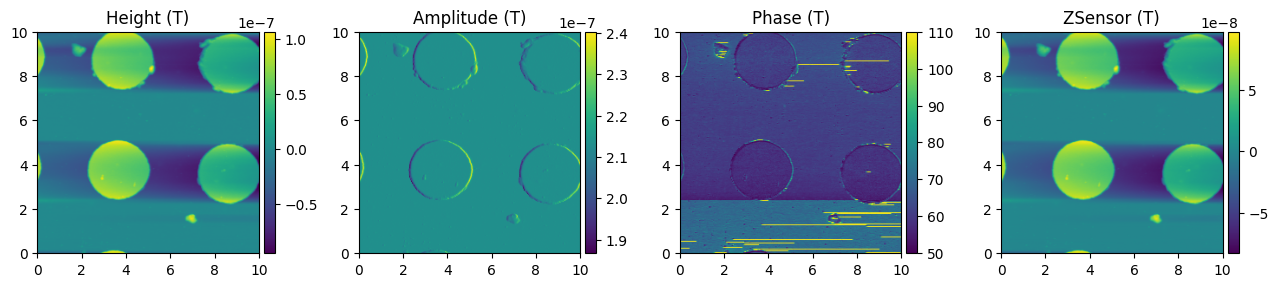

In [43]:
import aespm.tools as at
import pandas as pd
import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def find_channel(obj, key):
    if key is None:
        return np.arange(len(obj.channels))
    else:
        index = []
        channels = obj.channels

        for item in key:
            if item in channels:
                index.append(channels.index(item))
        return index


def display_ibw(file, key=None, titles=None, display_index=None, cmaps=None, save=None, **kwargs):
    '''
    Display a single ibw with specified by the file path.

    Input:
        file    - Required: path to the file to be displayed or the loaded ibw object returned by load_ibw()
        key     - Optional: list of channels to be displayed
        titles     - Optional: list of titles corresponding to the key
        display_index - Optional: index provided by display_ibw_folder() function
        cmaps     - Optional: list of color maps that will be used for each channels in key
        save     - Optional: if None, no image will be saved. If not None, each image will be 
                            saved as fileName + save
        **kwarg - Optional: Additional keyword arguments are sent to imshow().

    Output:
        ibw_files   -list: ibw file names in the same order as they are displayed
        data        -list: SciFiReader object of each ibw file displayed

    Example use:
        ibw_files, data = display_ibw(folder, mode='AC Mode', key=['Height', 'ZSensor'])
    '''

    try:
        if type(file) is str:
            t = load_ibw(file)
        else:
            t = file

        if key is not None:
            if not isinstance(key, list):
                key = list(key)
        else:
            key = t.channels

        if titles is not None:
            if not isinstance(titles, list):
                titles = list(titles)

        if cmaps is not None:
            if not isinstance(cmaps, list):
                cmaps = list(cmaps)

        if t.mode != 'Spec': # skip the spectrum ibw files
            indices = find_channel(obj=t, key=key)
            if len(indices) == 1: # Only one channel will be displayed
                plt.figure(figsize=[4,4])
                to_plot = t.data[indices[0]]
                if cmaps is None:
                    im = plt.imshow(to_plot, extent=[0, t.size*1e6, 0, t.size*1e6], **kwargs)
                else:
                    im = plt.imshow(to_plot, extent=[0, t.size*1e6, 0, t.size*1e6], cmap=cmaps[0], **kwargs)
                if display_index is None:
                    title = "{}: {}".format(t.mode, key[0]) if not titles else titles
                else:
                    title = "{}: {}-{}".format(display_index, t.mode, key[0]) if not titles else titles

                plt.title(title)
                divider = make_axes_locatable(plt.gca())
                cax = divider.append_axes("right", size="5%", pad=0.05)
                plt.colorbar(im, cax=cax)
                plt.tight_layout()
                if save is not None:
                    plt.savefig('{}.png'.format(save), dpi=400, bbox_inches='tight', pad_inches=0.1)
            else:
                n_cols = len(indices)
                fig,ax=plt.subplots(1, n_cols, figsize=[n_cols*3+1, 3])
                for i in range(len(indices)):
                    to_plot = t.data[indices[i]]
                    if cmaps is None:
                        im = ax[i].imshow(to_plot, extent=[0, t.size*1e6, 0, t.size*1e6], **kwargs)
                    else:
                        im = ax[i].imshow(to_plot, extent=[0, t.size*1e6, 0, t.size*1e6], cmap=cmaps[i], **kwargs)
                    divider = make_axes_locatable(ax[i])
                    cax = divider.append_axes("right", size="5%", pad=0.05)
                    fig.colorbar(im, cax=cax)
                    if titles is None:
                        if not i:
                            ax[i].set_title("{}: {}-{}".format(display_index, t.mode, t.channels[indices[i]]))
                        else:
                            ax[i].set_title("{}".format(t.channels[indices[i]]))
                    else:
                        ax[i].set_title(titles[i])
                    plt.tight_layout()
                    if save is not None:
                        plt.savefig('{}.png'.format(save), dpi=400, bbox_inches='tight', pad_inches=0.1)
        else:
            pass
    except TypeError:
        pass

def summarize_ibw_file(filename):
    """
    Prints a summary of information available in a .ibw file.
    """

    ibw = load_ibw(filename)

    print("File :", filename)
    print("Imaging Mode :", ibw.mode)
    print("Scan Size :", ibw.size)
    print("Header keys :", list(ibw.header.keys()))

    # Header keys are not defined for this sample, since they only go to four channels
    # Instead, we *know* the label style, so we can just give the channels each name and capture
    # the data that way.

    print("Available Channels :", ibw.channels)
    print("Data Shape :", ibw.data.shape)

    df = pd.DataFrame(ibw.data[0])
    df.to_csv('ibw_dataframe.csv', index=False)

    return ibw

def main():
    # Directory containing the .ibw files
    ibw_dir = "exp_data/June 18/read_out"

    # at.display_ibw_folder(ibw_dir, key=['Height', 'Phase', 'None'])

    # Directory containing the .ibw files
    ibw_dir = "exp_data/June 18/read_out"


    file_path = 'exp_data/June 18/read_out/Read_out_0035.ibw'
    summarize_ibw_file(file_path)
    display_ibw(file_path, 
                titles=['Height (T)', 'Amplitude (T)', 'Phase (T)', 'ZSensor (T)'],
                key=['Height (T)', 'Amplitude (T)', 'Phase (T)', 'ZSensor (T)'])

# titles=['Height (T)', 'Height (RT)', 'Amplitude (T)', 'Amplitude (RT)', 'Phase (T)', 'Phase (RT)', 'ZSensor (T)', 'ZSensor (RT)'])


if __name__ == "__main__":
    main()



## We can now access each image type for trace and retrace. This will be important for generalizing trends.



In [6]:
import numpy as np

# def compute_reward(ibw_data, trace_idx=0, retrace_idx=1):
#     """
#     Compute reward based on IBWData object.
#     - ibw_data: your loaded IBWData instance with attributes:
#       .data shape (channels, H, W), channels named in ibw_data.channels
#     - trace_idx and retrace_idx: indices corresponding to trace and retrace data slices,
#       if separate. If not separate, you may need to infer or segment.
    
#     Returns:
#         reward (float): higher is better
#     """
#     # Extract channels indices
#     ch_names = ibw_data.channels
    
#     # Height channel data: shape (H, W)
#     trace = ibw_data.data[ch_names.index('Height (T)')] 
#     retrace = ibw_data.data[ch_names.index('Height (RT)')]
    
#     # MAE between trace and retrace heights
#     mae_height = np.mean(np.abs(trace - retrace))
    
#     # Phase channel noise (std dev of phase difference trace vs retrace)
#     phase_trace = ibw_data.data[ch_names.index('Phase (T)')]
#     phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
#     phase_noise = np.std(phase_trace - phase_retrace)
    
#     # Metadata: scan rate (normalize reward by it)
#     scan_rate = ibw_data.header.get('ScanRate', 1.0)  # fallback to 1.0 if missing
    
#     # Compose reward: inverse of error & noise, normalized by scan rate
#     reward = 1 / (mae_height + 1e-6) + 1 / (phase_noise + 1e-6)
#     reward /= scan_rate
    
#     return reward

# ibw = load_ibw("exp_data/June 18/read_out/Read_out_0000.ibw")
# compute_reward(ibw)


In [7]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(pretrained=True)

# Replace final layer for custom number of classes (e.g., 10)
num_classes = 5
model.fc = nn.Linear(model.fc.in_features, num_classes)

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import aespm.tools as at  # your IBW loader module
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
import torch.nn.functional as F
os.environ['PYTORCH_DISABLE_DYNAMO'] = '1'


class AdaptiveLoss(nn.Module):
    def __init__(self):
        super(AdaptiveLoss, self).__init__()
        # Learnable weights for multi-task learning
        self.log_var_class = nn.Parameter(torch.zeros(1))
        self.log_var_reward = nn.Parameter(torch.zeros(1))
        
    def forward(self, class_pred, class_true, reward_pred, reward_true):
        # Classification loss
        class_loss = F.cross_entropy(class_pred, class_true)
        
        # Reward loss (MSE)
        reward_loss = F.mse_loss(reward_pred.squeeze(), reward_true)
        
        # Adaptive weighting based on uncertainty
        precision_class = torch.exp(-self.log_var_class)
        precision_reward = torch.exp(-self.log_var_reward)
        
        # Total loss with automatic balancing
        total_loss = (precision_class * class_loss + self.log_var_class + 
                     precision_reward * reward_loss + self.log_var_reward)
        
        return total_loss, class_loss, reward_loss


# --- Dataset class for loading IBW files ---
class IBWDataset(Dataset):
    def __init__(self, ibw_files, labels=None, transform=None, compute_rewards=False):
        self.ibw_files = ibw_files
        self.labels = labels
        self.transform = transform
        self.compute_rewards = compute_rewards
        
        # Pre-compute rewards if needed for efficiency
        if compute_rewards:
            self.rewards = []
            for i, file_path in enumerate(ibw_files):
                ibw_data = load_ibw(file_path)
                # Use improved reward function
                reward, _ = compute_reward(ibw_data, scan_index=i+1)
                self.rewards.append(reward)
            
            # Normalize rewards to have zero mean and unit variance
            self.rewards = np.array(self.rewards)
            self.reward_mean = np.mean(self.rewards)
            self.reward_std = np.std(self.rewards)
            if self.reward_std > 0:
                self.rewards = (self.rewards - self.reward_mean) / self.reward_std
            
            print(f"Reward normalization: mean={self.reward_mean:.4f}, std={self.reward_std:.4f}")

    def __len__(self):
        return len(self.ibw_files)

    def __getitem__(self, idx):
        file_path = self.ibw_files[idx]
        ibw_data = load_ibw(file_path)
        height_img = ibw_data.z  
        img_tensor = preprocess_height_channel(height_img, self.transform)

        result = [img_tensor]
        
        if self.labels is not None:
            result.append(self.labels[idx])
        
        if self.compute_rewards:
            result.append(self.rewards[idx])  # Already normalized
        
        result.append(idx + 1)  # scan_index
            
        return tuple(result)

def custom_collate(batch):
    """
    Handle variable batch contents based on what's included
    """
    batch_size = len(batch)
    item_count = len(batch[0])
    
    imgs = torch.stack([item[0] for item in batch], dim=0)
    
    result = [imgs]
    
    if item_count >= 2:  # has labels
        labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
        result.append(labels)
    
    if item_count >= 3:  # has rewards
        rewards = torch.tensor([item[2] for item in batch], dtype=torch.float32)
        result.append(rewards)
    
    if item_count >= 4:  # has scan indices
        scan_indices = torch.tensor([item[-1] for item in batch], dtype=torch.long)
        result.append(scan_indices)
    
    return tuple(result)

# --- Preprocessing function to convert height data to 3-channel tensor ---
def preprocess_height_channel(height_np_array, transform=None):
    """
    Normalize the Height channel to [0, 255], convert to PIL Image,
    duplicate single channel to 3 channels, apply transforms.
    """
    # Normalize to 0-255
    h_min = np.min(height_np_array)
    h_max = np.max(height_np_array)
    norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(norm_img)

    # Convert grayscale to RGB by duplicating channels
    pil_img = pil_img.convert("RGB")

    if transform:
        return transform(pil_img)
    else:
        # Default tensor transform if none given
        return transforms.ToTensor()(pil_img)

def compute_reward(ibw_data, scan_index=0, normalize_rewards=True):
    """
    Improved reward function with better scaling and additional quality metrics
    """
    ch_names = ibw_data.channels
    
    # Extract data
    height_trace = ibw_data.data[ch_names.index('Height (T)')] 
    height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
    phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
    phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]

    # We solely use the height/phase and trace retrace data to make this reward focus for the training.
    
    # Extract scan rate
    scan_rate = ibw_data.header.get('ScanRate', 1.0)
    
    rewards = {}
    
    # 1. Height Consistency (Trace vs Retrace)
    min_rows = min(height_trace.shape[0], height_retrace.shape[0])
    if min_rows > 0:
        height_diff = height_trace[:min_rows, :] - height_retrace[:min_rows, :]
        mae_height = np.mean(np.abs(height_diff))
        # Convert to similarity score (0 to 1, where 1 is perfect match)
        # Use exponential decay instead of inverse
        rewards['height_consistency'] = np.exp(-mae_height / np.std(height_trace))
    else:
        rewards['height_consistency'] = 0.0
    
    # 2. Phase Consistency (Trace vs Retrace)  
    min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])
    if min_rows_phase > 0:
        phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
        phase_std = np.std(phase_diff)
        # Normalize by the dynamic range of phase data
        phase_range = np.ptp(phase_trace)  # peak-to-peak
        if phase_range > 0:
            normalized_phase_std = phase_std / phase_range
            rewards['phase_consistency'] = np.exp(-5 * normalized_phase_std)  # More sensitive
        else:
            rewards['phase_consistency'] = 1.0
    else:
        rewards['phase_consistency'] = 0.0
    
    # 3. Image Sharpness/Focus (using gradient variance)
    height_gradients = np.gradient(height_trace)
    gradient_variance = np.var(height_gradients)
    # Normalize and convert to 0-1 score
    rewards['sharpness'] = np.tanh(gradient_variance / 1000.0)  # Adjust scaling as needed
    
    # # 4. Signal-to-Noise Ratio
    height_signal = np.mean(height_trace)
    height_noise = np.std(height_trace)
    if height_noise > 0:
        snr = abs(height_signal) / height_noise
        rewards['snr'] = np.tanh(snr / 10.0)  # Normalize SNR
    else:
        rewards['snr'] = 1.0
    
    # 5. Data Quality (check for artifacts, saturation, etc.)
    # Detect if data is clipped/saturated
    height_flat = height_trace.flatten()
    unique_values = len(np.unique(height_flat))
    total_pixels = len(height_flat)
    diversity_ratio = unique_values / total_pixels
    rewards['data_diversity'] = min(diversity_ratio * 10, 1.0)  # Scale to 0-1
    
    # 6. Scan Index Penalty (prefer earlier scans, indicating tip quality)
    # # Use exponential decay instead of linear
    # max_expected_scans = 35  # Adjust based on your typical experiment
    # rewards['tip_freshness'] = np.exp(-scan_index / max_expected_scans)
    
    # 7. Scan Rate Appropriateness (if you have an optimal range)
    optimal_scan_rate = 2.0  # Hz, adjust based on your system
    scan_rate_penalty = abs(scan_rate - optimal_scan_rate) / optimal_scan_rate
    rewards['scan_rate'] = np.exp(-scan_rate_penalty)
    
    # Combine rewards with learned or heuristic weights
    weights = {
        'height_consistency': 0.25,
        'phase_consistency': 0.25, 
        'sharpness': 0.15,
        'snr': 0.15,
        'data_diversity': 0.1,
        # 'tip_freshness': 0.08,
        'scan_rate': 0.02
    }
    
    # Weighted combination
    total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
    
    return total_reward, rewards  # `rewards` is the dictionary of components



def generate_labels_from_scan_indices(scan_indices):
    """
    Generate labels by dividing scan indices into 5 equal-sized groups.
    This ensures each group has roughly the same number of samples.
    """
    labels = []
    
    # Sort indices to get proper grouping
    sorted_indices = sorted(scan_indices)
    total_samples = len(sorted_indices)
    samples_per_group = total_samples / 5.0
    
    print(f"Total samples: {total_samples}, samples per group: {samples_per_group:.2f}")
    
    # Create a mapping from index to label
    index_to_label = {}
    for i, idx in enumerate(sorted_indices):
        label = min(int(i / samples_per_group), 4)  # Cap at class 4
        index_to_label[idx] = label
    
    # Apply mapping to original order
    for idx in scan_indices:
        labels.append(index_to_label[idx])
    
    print(f"Label distribution: {np.bincount(labels)}")
    print(f"Labels: {labels}")
    return labels

# --- Enhanced Model with Reward Prediction Head ---
class RewardAwareModel(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, dropout_rate=0.3):
        super(RewardAwareModel, self).__init__()
        # Base model
        self.backbone = models.resnet18(pretrained=pretrained)
        
        # Remove the final classification layer
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        
        # Get feature dimension
        feature_dim = self.backbone.fc.in_features
        
        # Add dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head with LayerNorm instead of BatchNorm
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.LayerNorm(256),  # LayerNorm works with any batch size
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Reward prediction head
        self.reward_predictor = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.LayerNorm(128),  # LayerNorm instead of BatchNorm
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
        
    def forward(self, x, return_features=False):
        # Extract features
        features = self.features(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction output
        reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            return class_output, reward_output

def validate_model(model, val_dataloader, device, use_adaptive_loss=False, criterion=None):
    model.eval()
    total_loss = 0.0
    results = []

    with torch.no_grad():
        for batch_data in val_dataloader:
            if len(batch_data) != 4:
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss and criterion:
                loss, _, _ = criterion(class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = F.cross_entropy(class_outputs, labels)
                reward_loss = F.mse_loss(reward_outputs.squeeze(), rewards)
                loss = class_loss + 0.1 * reward_loss
            
            total_loss += loss.item()

            # --- Collect predictions and metadata ---
            preds = torch.argmax(class_outputs, dim=1).cpu().numpy()
            true_labels = labels.cpu().numpy()
            true_rewards = rewards.cpu().numpy()
            pred_rewards = reward_outputs.cpu().numpy().flatten()
            scan_indices = scan_indices.cpu().numpy()

            for i in range(len(scan_indices)):
                scan_idx = scan_indices[i]

                # Get the original file path from dataset
                file_path = val_dataloader.dataset.dataset.ibw_files[scan_idx]
                ibw_data = at.load_ibw(file_path)  # aespm.tools.load_ibw

                # Recompute reward components
                try:
                    reward_total, reward_components = compute_reward(
                        ibw_data, scan_index=scan_idx, normalize_rewards=False
                    )
                except Exception as e:
                    print(f"Warning: Failed to compute reward for {file_path}: {e}")
                    reward_components = {}

                results.append({
                    'scan_index': int(scan_idx),
                    'file': os.path.basename(file_path),
                    'true_label': int(true_labels[i]),
                    'pred_label': int(preds[i]),
                    'true_reward': float(true_rewards[i]),
                    'pred_reward': float(pred_rewards[i]),
                    **reward_components
                })

    # --- Save to CSV ---
    df = pd.DataFrame(results)
    df.to_csv("validation_reward_analysis.csv", index=False)
    print("✅ Saved validation results to validation_reward_analysis.csv")

    return total_loss / len(val_dataloader)



def train_model(model, train_dataloader, val_dataloader, optimizer, device, 
                        num_epochs=10, use_adaptive_loss=True):
    
    if use_adaptive_loss:
        criterion = AdaptiveLoss().to(device)
        # Include adaptive loss parameters in optimizer
        optimizer = optim.Adam(list(model.parameters()) + list(criterion.parameters()), 
                              lr=1e-4, weight_decay=1e-5)
    else:
        classification_criterion = nn.CrossEntropyLoss()
        reward_criterion = nn.MSELoss()
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_reward_loss = 0.0
        
        for i, batch_data in enumerate(train_dataloader):
            if len(batch_data) != 4:  # Need all components
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss:
                total_loss, class_loss, reward_loss = criterion(
                    class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = classification_criterion(class_outputs, labels)
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                total_loss = class_loss + 0.1 * reward_loss  # Fixed weighting
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += total_loss.item()
            running_class_loss += class_loss.item()
            running_reward_loss += reward_loss.item()
        
        # Validation phase
        val_loss = validate_model(model, val_dataloader, device, use_adaptive_loss, criterion if use_adaptive_loss else None)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Statistics
        avg_train_loss = running_loss / len(train_dataloader)
        avg_class_loss = running_class_loss / len(train_dataloader)
        avg_reward_loss = running_reward_loss / len(train_dataloader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Class Loss: {avg_class_loss:.4f} | Reward Loss: {avg_reward_loss:.4f}")
        
        if use_adaptive_loss:
            print(f"  Adaptive weights - Class: {torch.exp(-criterion.log_var_class).item():.4f}, "
                  f"Reward: {torch.exp(-criterion.log_var_reward).item():.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'best_model.pth')
        
        print("-" * 50)
    
    return train_losses, val_losses


def evaluate_model(model, dataloader, device):
    """Evaluate the model and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_rewards_true = []
    all_rewards_pred = []
    
    with torch.no_grad():
        for batch_data in dataloader:
            if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
            elif len(batch_data) == 3:  # imgs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                rewards = None
            else:
                continue  # Need at least labels for evaluation
                
            inputs = inputs.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            # Get predictions
            _, predicted = torch.max(class_outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
            if rewards is not None:
                all_rewards_true.extend(rewards.numpy())
                all_rewards_pred.extend(reward_outputs.cpu().numpy().flatten())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Classification Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    if all_rewards_true:
        reward_mse = np.mean((np.array(all_rewards_true) - np.array(all_rewards_pred))**2)
        print(f"Reward Prediction MSE: {reward_mse:.4f}")
    
    return accuracy

import re
import os
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import transforms
import numpy as np

def extract_index_from_filename(filepath):
    """
    Extract the numeric index from IBW filename.
    E.g., 'Read_out_0032.ibw' -> 32, 'wear_out_0045.ibw' -> 45
    """
    filename = os.path.basename(filepath)
    # Look for pattern of digits (usually 4 digits) before .ibw
    match = re.search(r'(\d+)\.ibw$', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    else:
        raise ValueError(f"Could not extract index from filename: {filename}")

def load_ibw_files_with_indices(base_folder, subfolders):
    """
    Load IBW files from multiple subfolders and extract their indices.
    """
    all_files = []
    all_indices = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        # Get all .ibw files in this folder
        ibw_files = [
            os.path.join(folder_path, f) 
            for f in os.listdir(folder_path) 
            if f.lower().endswith(".ibw")
        ]
        
        # Extract indices and pair with file paths
        for filepath in ibw_files:
            try:
                index = extract_index_from_filename(filepath)
                all_files.append(filepath)
                all_indices.append(index)
            except ValueError as e:
                print(f"Warning: {e}")
                continue
    
    # Sort by index to maintain consistent ordering
    paired_data = list(zip(all_indices, all_files))
    paired_data.sort(key=lambda x: x[0])  # Sort by index
    
    sorted_indices, sorted_files = zip(*paired_data) if paired_data else ([], [])
    
    return list(sorted_files), list(sorted_indices)

def debug_dataset_and_labels(dataset, scan_indices, labels):
    """
    Debug function to check dataset and label compatibility.
    """
    print("\n=== DEBUGGING DATASET AND LABELS ===")
    print(f"Number of files: {len(dataset)}")
    print(f"Number of scan indices: {len(scan_indices)}")
    print(f"Number of labels: {len(labels)}")
    
    if len(labels) > 0:
        print(f"Label shape: {labels.shape if hasattr(labels, 'shape') else 'Not a tensor'}")
        print(f"Label dtype: {labels.dtype if hasattr(labels, 'dtype') else type(labels)}")
        print(f"Unique labels: {torch.unique(labels) if torch.is_tensor(labels) else set(labels)}")
        print(f"Min label: {torch.min(labels) if torch.is_tensor(labels) else min(labels)}")
        print(f"Max label: {torch.max(labels) if torch.is_tensor(labels) else max(labels)}")
    
    print(f"Scan indices range: {min(scan_indices)} to {max(scan_indices)}")
    
    # Check first few samples
    print("\nFirst few samples:")
    for i in range(min(3, len(dataset))):
        try:
            sample = dataset[i]
            if isinstance(sample, tuple) and len(sample) >= 2:
                image, label = sample[0], sample[1]
                print(f"Sample {i}: image shape = {image.shape}, label = {label}")
            else:
                print(f"Sample {i}: {type(sample)}")
        except Exception as e:
            print(f"Error loading sample {i}: {e}")
    
    print("=== END DEBUG ===\n")

def main():
    # Enable CUDA error checking for better debugging
    os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Define base folder and subfolders to search
    base_folder = "exp_data/June 18"
    subfolders = ["read_out", "wear_out"]
    
    # Load IBW files from both directories with their indices
    ibw_files, scan_indices = load_ibw_files_with_indices(base_folder, subfolders)
    
    print(f"Found {len(ibw_files)} IBW files total:")
    print(f"Indices range: {min(scan_indices) if scan_indices else 'N/A'} to {max(scan_indices) if scan_indices else 'N/A'}")
    
    # Print first few files and their indices for verification
    for i, (filepath, index) in enumerate(zip(ibw_files[:5], scan_indices[:5])):
        print(f"  {index}: {os.path.basename(filepath)} -> {os.path.dirname(filepath)}")
    if len(ibw_files) > 5:
        print(f"  ... and {len(ibw_files) - 5} more files")
    
    # Generate labels based on scan indices
    labels = generate_labels_from_scan_indices(scan_indices)
    print(f"Generated labels shape: {len(labels)} labels")
    
    # Convert labels to tensor for consistency
    labels = torch.tensor(labels, dtype=torch.long)

    # Define transforms to match ImageNet normalization & size
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])

    # Create dataset with reward computation
    dataset = IBWDataset(ibw_files, labels, transform, compute_rewards=True)
    
    # DEBUG: Check dataset and labels compatibility
    debug_dataset_and_labels(dataset, scan_indices, labels)
    
    # CRITICAL: Ensure labels are in correct range for your model
    if torch.is_tensor(labels):
        max_label = torch.max(labels).item()
        min_label = torch.min(labels).item()
    else:
        max_label = max(labels)
        min_label = min(labels)
    
    print(f"Label range: {min_label} to {max_label}")
    
    # Create model - MAKE SURE num_classes matches your actual number of classes
    # If your labels range from 0 to 4, you need num_classes=5
    # If your labels range from 1 to 5, you need to adjust labels or num_classes
    actual_num_classes = max_label - min_label + 1
    print(f"Detected {actual_num_classes} classes (labels {min_label} to {max_label})")
    
    # Adjust labels to be 0-indexed if they aren't already
    if min_label != 0:
        print(f"Adjusting labels to be 0-indexed (subtracting {min_label})")
        if torch.is_tensor(labels):
            labels = labels - min_label
        else:
            labels = [l - min_label for l in labels]
        # Update dataset with adjusted labels
        dataset = IBWDataset(ibw_files, labels, transform, compute_rewards=True)
    
    model = RewardAwareModel(num_classes=actual_num_classes, pretrained=True)
    model = model.to(device)
    
    # Split dataset for training and validation
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=custom_collate)
    val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=custom_collate)

    # Test dataloader
    print("Testing dataloader...")
    try:
        test_batch = next(iter(train_dataloader))
        if isinstance(test_batch, tuple) and len(test_batch) >= 2:
            batch_images, batch_labels = test_batch[0], test_batch[1]
            print(f"Batch images shape: {batch_images.shape}")
            print(f"Batch labels shape: {batch_labels.shape}")
            print(f"Batch labels: {batch_labels}")
            print("Dataloader test successful!")
        else:
            print(f"Unexpected batch format: {type(test_batch)}")
    except Exception as e:
        print(f"Dataloader test failed: {e}")
        return

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    
    print("Starting training...")
    train_model(model, train_dataloader, val_dataloader, optimizer, device, 
                num_epochs=10)

    print("\nEvaluating on validation set...")
    evaluate_model(model, val_dataloader, device)
    
    # Save the trained model with metadata
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'file_indices': scan_indices,
        'file_paths': ibw_files,
        'num_classes': actual_num_classes,
        'label_adjustment': min_label,
        'num_files_per_folder': {
            'read_out': len([f for f in ibw_files if 'read_out' in f]),
            'wear_out': len([f for f in ibw_files if 'wear_out' in f])
        }
    }, 'ibw_reward_model.pth')
    
    print("Model saved as 'ibw_reward_model.pth'")
    print(f"Training completed with {len(ibw_files)} total files from both directories")

if __name__ == "__main__":
    main()

Using device: cuda
Found 71 IBW files total:
Indices range: 0 to 35
  0: Read_out_0000.ibw -> exp_data/June 18\read_out
  0: Wear_out_0000.ibw -> exp_data/June 18\wear_out
  1: Read_out_0001.ibw -> exp_data/June 18\read_out
  1: Wear_out_0001.ibw -> exp_data/June 18\wear_out
  2: Read_out_0002.ibw -> exp_data/June 18\read_out
  ... and 66 more files
Total samples: 71, samples per group: 14.20
Label distribution: [14 14 14 14 15]
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Generated labels shape: 71 labels
Reward normalization: mean=0.5052, std=0.0260

=== DEBUGGING DATASET AND LABELS ===
Number of files: 71
Number of scan indices: 71
Number of labels: 71
Label shape: torch.Size([71])
Label dtype: torch.int64
Unique labels: tensor([0, 1, 2, 3, 4])
Min label: 0
Max label: 4
Scan indices range: 0 to 35

First few 

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Batch images shape: torch.Size([4, 3, 224, 224])
Batch labels shape: torch.Size([4])
Batch labels: tensor([0, 2, 4, 3])
Dataloader test successful!
Starting training...


KeyboardInterrupt: 

In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import aespm.tools as at  # your IBW loader module
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
import torch.nn.functional as F
import random
import traceback


class AdaptiveLoss(nn.Module):
    def __init__(self):
        super(AdaptiveLoss, self).__init__()
        # Learnable weights for multi-task learning
        self.log_var_class = nn.Parameter(torch.zeros(1))
        self.log_var_reward = nn.Parameter(torch.zeros(1))
        
    def forward(self, class_pred, class_true, reward_pred, reward_true):
        # Classification loss
        class_loss = F.cross_entropy(class_pred, class_true)
        
        # Reward loss (MSE)
        reward_loss = F.mse_loss(reward_pred.squeeze(), reward_true)
        
        # Adaptive weighting based on uncertainty
        precision_class = torch.exp(-self.log_var_class)
        precision_reward = torch.exp(-self.log_var_reward)
        
        # Total loss with automatic balancing
        total_loss = (precision_class * class_loss + self.log_var_class + 
                     precision_reward * reward_loss + self.log_var_reward)
        
        return total_loss, class_loss, reward_loss


def load_multi_dataset(base_folders, dataset_names):
    """
    Load IBW files from multiple datasets and maintain proper scan indices
    
    Args:
        base_folders: list of base folder paths
        dataset_names: list of dataset subfolder names
    
    Returns:
        all_files: list of all IBW file paths
        all_labels: list of corresponding labels
        all_scan_indices: list of scan indices
        dataset_info: dict with dataset metadata
    """
    all_files = []
    all_labels = []
    all_scan_indices = []
    dataset_info = {}
    
    for base_folder in base_folders:
        for dataset_name in dataset_names:
            dataset_path = os.path.join(base_folder, dataset_name)
            
            if not os.path.exists(dataset_path):
                print(f"Warning: Dataset path {dataset_path} does not exist, skipping...")
                continue
                
            # Get all IBW files for this dataset
            ibw_files = sorted([
                os.path.join(dataset_path, f) 
                for f in os.listdir(dataset_path) 
                if f.lower().endswith(".ibw")
            ])
            
            if not ibw_files:
                print(f"Warning: No IBW files found in {dataset_path}, skipping...")
                continue
            
            print(f"Found {len(ibw_files)} IBW files in {dataset_path}")
            
            # Generate scan indices for this dataset (1-based)
            scan_indices = list(range(1, len(ibw_files) + 1))
            
            # Generate labels based on scan indices
            labels = generate_labels_from_scan_indices(scan_indices)
            
            # Store dataset info
            dataset_key = f"{os.path.basename(base_folder)}_{dataset_name}"
            dataset_info[dataset_key] = {
                'files': ibw_files,
                'labels': labels,
                'scan_indices': scan_indices,
                'count': len(ibw_files)
            }
            
            # Add to master lists
            all_files.extend(ibw_files)
            all_labels.extend(labels)
            all_scan_indices.extend(scan_indices)
    
    print(f"\nTotal files loaded: {len(all_files)}")
    print(f"Dataset breakdown:")
    for key, info in dataset_info.items():
        print(f"  {key}: {info['count']} files")
    
    return all_files, all_labels, all_scan_indices, dataset_info


class AugmentedTransform:
    """
    Custom transform class that handles the comprehensive data augmentation
    """
    def __init__(self, base_size=224, crop_size=75, normalize=True):
        self.base_size = base_size
        self.crop_size = crop_size
        self.normalize = normalize
        
        # Define normalization if requested
        if normalize:
            self.normalize_transform = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        else:
            self.normalize_transform = None
    
    def __call__(self, pil_image):
        """
        Apply the full augmentation pipeline to a single PIL image
        Returns a list of transformed tensors
        """
        # First resize to base size
        resize_transform = transforms.Resize((self.base_size, self.base_size))
        resized_img = resize_transform(pil_image)
        
        augmented_images = []
        
        # Step 1: Create 9 crops (3x3 grid)
        crops = self._create_crops(resized_img)
        
        # Step 2: For each crop, create 4 rotations
        rotated_crops = []
        for crop in crops:
            for angle in [0, 90, 180, 270]:
                rotated = transforms.functional.rotate(crop, angle)
                rotated_crops.append(rotated)
        
        # Step 3: For each rotated crop, create original + horizontal flip
        for rotated_crop in rotated_crops:
            # Original
            tensor_orig = self._to_tensor_and_normalize(rotated_crop)
            augmented_images.append(tensor_orig)
            
            # Horizontally flipped
            flipped = transforms.functional.hflip(rotated_crop)
            tensor_flipped = self._to_tensor_and_normalize(flipped)
            augmented_images.append(tensor_flipped)
        
        return augmented_images
    
    def _create_crops(self, img):
        """Create 9 crops from the image in a 3x3 grid"""
        crops = []
        w, h = img.size
        
        # Calculate crop positions for 3x3 grid
        crop_w = self.crop_size
        crop_h = self.crop_size
        
        # Evenly distribute crops across the image
        x_positions = [0, (w - crop_w) // 2, w - crop_w]
        y_positions = [0, (h - crop_h) // 2, h - crop_h]
        
        for y in y_positions:
            for x in x_positions:
                crop = img.crop((x, y, x + crop_w, y + crop_h))
                # Resize crop back to base_size for consistency
                crop = crop.resize((self.base_size, self.base_size))
                crops.append(crop)
        
        return crops
    
    def _to_tensor_and_normalize(self, pil_img):
        """Convert PIL image to tensor and apply normalization"""
        tensor = transforms.ToTensor()(pil_img)
        if self.normalize_transform:
            tensor = self.normalize_transform(tensor)
        return tensor


# --- Enhanced Dataset class with data augmentation ---
class AugmentedIBWDataset(Dataset):
    def __init__(self, ibw_files, labels=None, scan_indices=None, 
                 compute_rewards=False, use_augmentation=True, 
                 augmentation_factor=72):
        """
        Args:
            ibw_files: list of IBW file paths
            labels: list of labels for each file
            scan_indices: list of scan indices for each file
            compute_rewards: whether to compute rewards
            use_augmentation: whether to apply data augmentation
            augmentation_factor: number of augmented images per original (default 72)
        """
        self.ibw_files = ibw_files
        self.labels = labels if labels is not None else [0] * len(ibw_files)
        self.scan_indices = scan_indices if scan_indices is not None else list(range(1, len(ibw_files) + 1))
        self.compute_rewards = compute_rewards
        self.use_augmentation = use_augmentation
        self.augmentation_factor = augmentation_factor

        # Valid indices (all indices by default)
        self.valid_indices = list(range(len(self.ibw_files)))

        # IBW cache (optional, not used unless implemented)
        self.ibw_cache = {}

        # Initialize augmentation transform
        if use_augmentation:
            self.augment_transform = AugmentedTransform(base_size=224, crop_size=75)
        
        # Pre-compute rewards if needed
        if compute_rewards:
            print("Computing rewards for all images...")
            self.rewards = []
            for i, file_path in enumerate(ibw_files):
                ibw_data = load_ibw(file_path)
                reward = compute_reward(ibw_data, scan_index=self.scan_indices[i])
                self.rewards.append(reward)
            
            # Normalize rewards
            self.rewards = np.array(self.rewards)
            self.reward_mean = np.mean(self.rewards)
            self.reward_std = np.std(self.rewards)
            if self.reward_std > 0:
                self.rewards = (self.rewards - self.reward_mean) / self.reward_std
            
            print(f"Reward normalization: mean={self.reward_mean:.4f}, std={self.reward_std:.4f}")

    def __len__(self):
        if self.use_augmentation:
            return len(self.ibw_files) * self.augmentation_factor
        else:
            return len(self.ibw_files)

    def __getitem__(self, idx):
        try:
            if self.use_augmentation:
                # Calculate which original image and which augmentation
                original_idx_pos = idx // self.augmentation_factor
                aug_idx = idx % self.augmentation_factor
            else:
                original_idx_pos = idx
                aug_idx = 0
            
            # Get the actual file index
            original_idx = self.valid_indices[original_idx_pos]
            
            # Load the IBW data
            if self.compute_rewards and original_idx in self.ibw_cache:
                ibw_data = self.ibw_cache[original_idx]
            else:
                file_path = self.ibw_files[original_idx]
                ibw_data = load_ibw(file_path)
                if ibw_data is None:
                    # Return a fallback item
                    return self._get_fallback_item(original_idx)
            
            height_img = ibw_data.z
            
            # Convert to PIL image
            pil_img = self._height_to_pil(height_img)
            
            if self.use_augmentation:
                # Get all augmented versions
                augmented_tensors = self.augment_transform(pil_img)
                if aug_idx < len(augmented_tensors):
                    img_tensor = augmented_tensors[aug_idx]
                else:
                    img_tensor = augmented_tensors[0]  # Fallback
            else:
                # Simple preprocessing without augmentation
                img_tensor = self._simple_preprocess(height_img)
            
            result = [img_tensor]
            
            # Add label (same for all augmentations of the same image)
            if self.labels is not None:
                result.append(self.labels[original_idx])
            
            # Add reward (same for all augmentations of the same image)
            if self.compute_rewards:
                result.append(self.rewards[original_idx])
            
            # Add scan index
            result.append(self.scan_indices[original_idx])
            
            return tuple(result)
            
        except Exception as e:
            print(f"Error in __getitem__ at index {idx}: {e}")
            traceback.print_exc()
            return self._get_fallback_item(0)

    def _get_fallback_item(self, idx):
        # Return a dummy tensor and default values for label, reward, scan_index
        dummy_tensor = torch.zeros(3, 224, 224)
        label = 0
        reward = 0.0
        scan_index = 0
        result = [dummy_tensor]
        if self.labels is not None:
            result.append(label)
        if self.compute_rewards:
            result.append(reward)
        result.append(scan_index)
        return tuple(result)

    def _height_to_pil(self, height_np_array):
        """Convert height numpy array to PIL Image"""
        # Normalize to 0-255
        h_min = np.min(height_np_array)
        h_max = np.max(height_np_array)
        norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
        norm_img = norm_img.astype(np.uint8)
        
        # Convert to PIL image and make RGB
        pil_img = Image.fromarray(norm_img)
        pil_img = pil_img.convert("RGB")
        
        return pil_img


def custom_collate(batch):
    """
    Handle variable batch contents based on what's included
    """
    batch_size = len(batch)
    item_count = len(batch[0])
    
    imgs = torch.stack([item[0] for item in batch], dim=0)
    
    result = [imgs]
    
    if item_count >= 2:  # has labels
        labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
        result.append(labels)
    
    if item_count >= 3:  # has rewards
        rewards = torch.tensor([item[2] for item in batch], dtype=torch.float32)
        result.append(rewards)
    
    if item_count >= 4:  # has scan indices
        scan_indices = torch.tensor([item[-1] for item in batch], dtype=torch.long)
        result.append(scan_indices)
    
    return tuple(result)

# --- Keep all the existing preprocessing and model functions ---
def preprocess_height_channel(height_np_array, transform=None):
    """
    Normalize the Height channel to [0, 255], convert to PIL Image,
    duplicate single channel to 3 channels, apply transforms.
    """
    # Normalize to 0-255
    h_min = np.min(height_np_array)
    h_max = np.max(height_np_array)
    norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(norm_img)

    # Convert grayscale to RGB by duplicating channels
    pil_img = pil_img.convert("RGB")

    if transform:
        return transform(pil_img)
    else:
        # Default tensor transform if none given
        return transforms.ToTensor()(pil_img)

def compute_reward(ibw_data, scan_index=0, normalize_rewards=True):
    """
    Improved reward function with better scaling and additional quality metrics
    """
    ch_names = ibw_data.channels
    
    # Extract data
    height_trace = ibw_data.data[ch_names.index('Height (T)')] 
    height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
    phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
    phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
    
    # Extract scan rate
    scan_rate = ibw_data.header.get('ScanRate', 1.0)
    
    rewards = {}
    
    # 1. Height Consistency (Trace vs Retrace)
    min_rows = min(height_trace.shape[0], height_retrace.shape[0])
    if min_rows > 0:
        height_diff = height_trace[:min_rows, :] - height_retrace[:min_rows, :]
        mae_height = np.mean(np.abs(height_diff))
        # Convert to similarity score (0 to 1, where 1 is perfect match)
        # Use exponential decay instead of inverse
        rewards['height_consistency'] = np.exp(-mae_height / np.std(height_trace))
    else:
        rewards['height_consistency'] = 0.0
    
    # 2. Phase Consistency (Trace vs Retrace)  
    min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])
    if min_rows_phase > 0:
        phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
        phase_std = np.std(phase_diff)
        # Normalize by the dynamic range of phase data
        phase_range = np.ptp(phase_trace)  # peak-to-peak
        if phase_range > 0:
            normalized_phase_std = phase_std / phase_range
            rewards['phase_consistency'] = np.exp(-5 * normalized_phase_std)  # More sensitive
        else:
            rewards['phase_consistency'] = 1.0
    else:
        rewards['phase_consistency'] = 0.0
    
    # 3. Image Sharpness/Focus (using gradient variance)
    height_gradients = np.gradient(height_trace)
    gradient_variance = np.var(height_gradients)
    # Normalize and convert to 0-1 score
    rewards['sharpness'] = np.tanh(gradient_variance / 1000.0)  # Adjust scaling as needed
    
    # 4. Signal-to-Noise Ratio
    height_signal = np.mean(height_trace)
    height_noise = np.std(height_trace)
    if height_noise > 0:
        snr = abs(height_signal) / height_noise
        rewards['snr'] = np.tanh(snr / 10.0)  # Normalize SNR
    else:
        rewards['snr'] = 1.0
    
    # 5. Data Quality (check for artifacts, saturation, etc.)
    # Detect if data is clipped/saturated
    height_flat = height_trace.flatten()
    unique_values = len(np.unique(height_flat))
    total_pixels = len(height_flat)
    diversity_ratio = unique_values / total_pixels
    rewards['data_diversity'] = min(diversity_ratio * 10, 1.0)  # Scale to 0-1
    
    # 6. Scan Index Penalty (prefer earlier scans, indicating tip quality)
    # Use exponential decay instead of linear
    max_expected_scans = 35  # Adjust based on your typical experiment
    rewards['tip_freshness'] = np.exp(-scan_index / max_expected_scans)
    
    # 7. Scan Rate Appropriateness (if you have an optimal range)
    optimal_scan_rate = 2.0  # Hz, adjust based on your system
    scan_rate_penalty = abs(scan_rate - optimal_scan_rate) / optimal_scan_rate
    rewards['scan_rate'] = np.exp(-scan_rate_penalty)
    
    # Combine rewards with learned or heuristic weights
    weights = {
        'height_consistency': 0.20,
        'phase_consistency': 0.20, 
        'sharpness': 0.1,
        'snr': 0.1,
        'data_diversity': 0.1,
        'tip_freshness': 0.20,
        'scan_rate': 0.1
    }
    
    # Weighted combination
    total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
    
    return total_reward


def generate_labels_from_scan_indices(scan_indices):
    """
    Generate classification labels based on scan indices.
    Break them into 5 groups based on index
    """
    labels = []
    group_size = int(np.ceil(len(scan_indices) / 5))
    for idx in scan_indices:
        # Convert 1-based index to 0-based, then divide by group_size
        label = min((idx - 1) // group_size, 4)  # Cap at class 4
        labels.append(label)
    return labels

# --- Enhanced Model with Reward Prediction Head ---
class RewardAwareModel(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, dropout_rate=0.3):
        super(RewardAwareModel, self).__init__()
        # Base model
        self.backbone = models.resnet18(pretrained=pretrained)
        
        # Remove the final classification layer
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        
        # Get feature dimension
        feature_dim = self.backbone.fc.in_features
        
        # Add dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head with batch normalization
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Reward prediction head
        self.reward_predictor = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
        
    def forward(self, x, return_features=False):
        # Extract features
        features = self.features(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction output
        reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            return class_output, reward_output

def validate_model(model, val_dataloader, device, use_adaptive_loss=False, criterion=None):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch_data in val_dataloader:
            if len(batch_data) != 4:
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss and criterion:
                loss, _, _ = criterion(class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = F.cross_entropy(class_outputs, labels)
                reward_loss = F.mse_loss(reward_outputs.squeeze(), rewards)
                loss = class_loss + 0.1 * reward_loss
            
            total_loss += loss.item()
    
    return total_loss / len(val_dataloader)


def train_model(model, train_dataloader, val_dataloader, optimizer, device, 
                        num_epochs=10, use_adaptive_loss=True):
    
    if use_adaptive_loss:
        criterion = AdaptiveLoss().to(device)
        # Include adaptive loss parameters in optimizer
        optimizer = optim.Adam(list(model.parameters()) + list(criterion.parameters()), 
                              lr=1e-4, weight_decay=1e-5)
    else:
        classification_criterion = nn.CrossEntropyLoss()
        reward_criterion = nn.MSELoss()
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_reward_loss = 0.0
        
        for i, batch_data in enumerate(train_dataloader):
            if len(batch_data) != 4:  # Need all components
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss:
                total_loss, class_loss, reward_loss = criterion(
                    class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = classification_criterion(class_outputs, labels)
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                total_loss = class_loss + 0.1 * reward_loss  # Fixed weighting
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += total_loss.item()
            running_class_loss += class_loss.item()
            running_reward_loss += reward_loss.item()
            
            # Print progress every 100 batches
            if (i + 1) % 100 == 0:
                print(f"  Batch {i+1}/{len(train_dataloader)}, Loss: {total_loss.item():.4f}")
        
        # Validation phase
        val_loss = validate_model(model, val_dataloader, device, use_adaptive_loss, criterion if use_adaptive_loss else None)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Statistics
        avg_train_loss = running_loss / len(train_dataloader)
        avg_class_loss = running_class_loss / len(train_dataloader)
        avg_reward_loss = running_reward_loss / len(train_dataloader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Class Loss: {avg_class_loss:.4f} | Reward Loss: {avg_reward_loss:.4f}")
        
        if use_adaptive_loss:
            print(f"  Adaptive weights - Class: {torch.exp(-criterion.log_var_class).item():.4f}, "
                  f"Reward: {torch.exp(-criterion.log_var_reward).item():.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'best_model.pth')
        
        print("-" * 50)
    
    return train_losses, val_losses


def evaluate_model(model, dataloader, device):
    """Evaluate the model and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_rewards_true = []
    all_rewards_pred = []
    
    with torch.no_grad():
        for batch_data in dataloader:
            if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
            elif len(batch_data) == 3:  # imgs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                rewards = None
            else:
                continue  # Need at least labels for evaluation
                
            inputs = inputs.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            # Get predictions
            _, predicted = torch.max(class_outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
            if rewards is not None:
                all_rewards_true.extend(rewards.numpy())
                all_rewards_pred.extend(reward_outputs.cpu().numpy().flatten())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Classification Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    if all_rewards_true:
        reward_mse = np.mean((np.array(all_rewards_true) - np.array(all_rewards_pred))**2)
        print(f"Reward Prediction MSE: {reward_mse:.4f}")
    
    return accuracy

# --- Main script ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load multiple datasets
    base_folders = ["exp_data/June 18"]
    dataset_names = ["read_out", "wear_out"]
    
    all_files, all_labels, all_scan_indices, dataset_info = load_multi_dataset(
        base_folders, dataset_names
    )
    
    print(f"\nDataset Summary:")
    print(f"Total files: {len(all_files)}")
    print(f"Label distribution: {np.bincount(all_labels)}")
    
    # Create augmented dataset
    print("\nCreating augmented dataset...")
    dataset = AugmentedIBWDataset(
        all_files, 
        all_labels, 
        all_scan_indices,
        compute_rewards=True,
        use_augmentation=True,
        augmentation_factor=72  # 9 crops * 4 rotations * 2 flips
    )
    
    print(f"Augmented dataset size: {len(dataset)} samples")
    print(f"Augmentation ratio: {len(dataset) / len(all_files):.1f}x")
    
    # Split dataset for training and validation
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    # Create dataloaders with smaller batch size due to increased data
    train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, 
                                 collate_fn=custom_collate, num_workers=0)
    val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, 
                               collate_fn=custom_collate, num_workers=0)
    
    print(f"Training batches: {len(train_dataloader)}")
    print(f"Validation batches: {len(val_dataloader)}")

    # Create model
    model = RewardAwareModel(num_classes=5, pretrained=True)
    model = model.to(device)

    # Optimizer with adjusted learning rate for larger dataset
    optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)

    print("\nStarting training...")
    train_losses, val_losses = train_model(
        model, train_dataloader, val_dataloader, optimizer, device, 
        num_epochs=1, use_adaptive_loss=True
    )

    print("\nEvaluating on validation set...")
    evaluate_model(model, val_dataloader, device)
    
    # Save the trained model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, 'ibw_reward_model.pth')
    
    print("Model saved as 'ibw_reward_model.pth'")

if __name__ == "__main__":
    main()

Using device: cuda
Found 36 IBW files in exp_data/June 18\read_out
Found 35 IBW files in exp_data/June 18\wear_out

Total files loaded: 71
Dataset breakdown:
  June 18_read_out: 36 files
  June 18_wear_out: 35 files

Dataset Summary:
Total files: 71
Label distribution: [15 15 15 15 11]

Creating augmented dataset...
Computing rewards for all images...
Reward normalization: mean=0.6319, std=0.0388
Augmented dataset size: 5112 samples
Augmentation ratio: 72.0x
Training batches: 256
Validation batches: 64


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting training...
  Batch 100/256, Loss: 1.6873
  Batch 200/256, Loss: 1.6804
Epoch 1/1
  Train Loss: 1.8374 | Val Loss: 1.3676
  Class Loss: 1.2253 | Reward Loss: 0.6176
  Adaptive weights - Class: 0.9888, Reward: 1.0227
--------------------------------------------------

Evaluating on validation set...
Classification Accuracy: 0.5533

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.99      0.69       208
           1       0.39      0.27      0.32       211
           2       0.50      0.44      0.47       206
           3       0.53      0.35      0.43       229
           4       0.87      0.78      0.82       169

    accuracy                           0.55      1023
   macro avg       0.56      0.57      0.54      1023
weighted avg       0.55      0.55      0.53      1023

Reward Prediction MSE: 0.4120
Model saved as 'ibw_reward_model.pth'


In [ ]:
def load_trained_model(model_path, num_classes=5, device='cpu'):
    """
    Load a trained model from saved checkpoint
    
    Args:
        model_path: Path to saved model (.pth file)
        num_classes: Number of quality classes
        device: PyTorch device
    
    Returns:
        Loaded model ready for inference
    """
    model = RewardAwareModel(num_classes=num_classes, pretrained=False)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"Model loaded from {model_path}")
    return model

def predict_single_ibw(model, ibw_file_path, transform, device, 
                       reward_mean=None, reward_std=None, scan_index=None):
    """
    Predict quality class and reward for a single IBW file
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_path: Path to the IBW file
        transform: Image transforms to apply (MUST match training transforms exactly)
        device: PyTorch device
        reward_mean: Mean used for reward normalization during training
        reward_std: Std used for reward normalization during training
        scan_index: Actual scan index if known (for fair comparison)
    
    Returns:
        dict with prediction results
    """
    model.eval()
    
    try:
        # Load and preprocess the IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        img_tensor = preprocess_height_channel(height_img, transform)
        
        # Add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_outputs, reward_outputs = model(img_tensor)
            
            # Get predicted class
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            
            # Get predicted reward (this is normalized if training used normalization)
            predicted_reward_normalized = reward_outputs.item()
            
            # Convert back to original scale if normalization was used
            if reward_mean is not None and reward_std is not None and reward_std > 0:
                predicted_reward_original = predicted_reward_normalized * reward_std + reward_mean
            else:
                predicted_reward_original = predicted_reward_normalized
            
            # Compute actual reward for comparison (use same function as training!)
            if scan_index is not None:
                actual_reward = compute_reward(ibw_data, scan_index=scan_index)
            else:
                # If scan_index unknown, use 0 but note this affects comparison
                actual_reward = compute_reward(ibw_data, scan_index=0)
            
        # Create quality description
        quality_descriptions = {
            0: "Excellent (Class 0)",
            1: "Good (Class 1)", 
            2: "Fair (Class 2)",
            3: "Poor (Class 3)",
            4: "Bad (Class 4)"
        }
        
        result = {
            'file_path': ibw_file_path,
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward_normalized': predicted_reward_normalized,
            'predicted_reward_original': predicted_reward_original,
            'actual_reward': actual_reward,
            'reward_difference': abs(predicted_reward_original - actual_reward),
            'scan_index_used': scan_index if scan_index is not None else 0
        }
        
        return result
        
    except Exception as e:
        return {
            'file_path': ibw_file_path,
            'error': str(e),
            'predicted_class': None
        }

def predict_with_training_metadata(model, ibw_file_paths, model_metadata_path, device):
    """
    Predict using the same normalization parameters as training
    
    Args:
        model: Trained model
        ibw_file_paths: List of IBW file paths
        model_metadata_path: Path to saved training metadata (pickle file)
        device: PyTorch device
    
    Returns:
        List of prediction results
    """
    import pickle
    
    # Load training metadata
    try:
        with open(model_metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        
        transform = metadata['transform']
        reward_mean = metadata.get('reward_mean', None)
        reward_std = metadata.get('reward_std', None)
        file_to_index = metadata.get('file_to_index', {})  # Maps file paths to scan indices
        
        print(f"Loaded training metadata:")
        print(f"  Reward normalization - Mean: {reward_mean}, Std: {reward_std}")
        print(f"  Transform: {transform}")
        
    except FileNotFoundError:
        print("Warning: No metadata file found. Using default parameters.")
        # Use same transform as training
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225]),
        ])
        reward_mean = reward_std = None
        file_to_index = {}
    
    results = []
    
    print(f"Predicting quality for {len(ibw_file_paths)} files...")
    
    for i, file_path in enumerate(ibw_file_paths):
        print(f"Processing file {i+1}/{len(ibw_file_paths)}: {file_path}")
        
        # Get scan index if available from training
        scan_index = file_to_index.get(file_path, i + 1)  # Default to position-based index
        
        result = predict_single_ibw(model, file_path, transform, device, 
                                  reward_mean, reward_std, scan_index)
        results.append(result)
        
        if 'error' not in result:
            print(f"  Predicted: Class {result['predicted_class']} ({result['quality_description']}) "
                  f"with {result['confidence']:.3f} confidence")
        else:
            print(f"  Error: {result['error']}")
    
    return results

def extract_scan_index_from_filename(file_path):
    """
    Extract scan index from Igor-style filenames
    
    Args:
        file_path: Path like "exp_data/June 18/wear_out/Wear_out_0015.ibw"
    
    Returns:
        int: Scan index (e.g., 15 from "0015")
    """
    import re
    import os
    
    filename = os.path.basename(file_path)
    
    # Look for pattern like "_0015" or similar 4-digit numbers
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    
    # Fallback: look for any number sequence
    match = re.search(r'(\d+)', filename)
    if match:
        print(f"Found index from filename: {int(match.group())}")
        return int(match.group(1))
    
    # Default fallback
    print(f"Could not find index from filename.")
    return 0

def predict_single_ibw_simple(model, ibw_file_path, transform, device, 
                             reward_mean=None, reward_std=None):
    """
    Simple prediction function that extracts scan index from filename
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_path: Path to the IBW file
        transform: Image transforms (must match training exactly)
        device: PyTorch device
        reward_mean: Mean used for reward normalization during training
        reward_std: Std used for reward normalization during training
    
    Returns:
        dict with prediction results
    """
    model.eval()
    
    try:
        # Extract scan index from filename
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        print(f"Found scan index: {scan_index}")
        
        # Load and preprocess the IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        img_tensor = preprocess_height_channel(height_img, transform)
        
        # Add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_outputs, reward_outputs = model(img_tensor)
            
            # Get predicted class
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            
            # Get predicted reward (normalized if training used normalization)
            predicted_reward_normalized = reward_outputs.item()
            
            # Convert back to original scale if normalization was used
            if reward_mean is not None and reward_std is not None and reward_std > 0:
                predicted_reward_original = predicted_reward_normalized * reward_std + reward_mean
            else:
                predicted_reward_original = predicted_reward_normalized
            
            # Compute actual reward using same function as training
            actual_reward = compute_reward(ibw_data, scan_index=scan_index)
            
        # Create quality description
        quality_descriptions = {
            0: "Excellent (Class 0)",
            1: "Good (Class 1)", 
            2: "Fair (Class 2)",
            3: "Poor (Class 3)",
            4: "Bad (Class 4)"
        }
        
        result = {
            'file_path': ibw_file_path,
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward_normalized': predicted_reward_normalized,
            'predicted_reward_original': predicted_reward_original,
            'actual_reward': actual_reward,
            'reward_difference': abs(predicted_reward_original - actual_reward),
            'scan_index': scan_index
        }
        
        return result
        
    except Exception as e:
        return {
            'file_path': ibw_file_path,
            'error': str(e),
            'predicted_class': None
        }

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from 4_perfect.pth
File : exp_data/June 18/read_out/Read_out_0000.ibw
Imaging Mode : AC Mode
Scan Size : 1e-05
Header keys : ['ScanSize', 'FastScanSize', 'SlowScanSize', 'ScanRate', 'XOffset', 'YOffset', 'PointsLines', 'ScanPoints', 'ScanLines', 'ScanAngle', 'ImagingMode', 'InvOLS', 'SpringConstant', 'AmpInvOLS', 'Amp2Invols', 'FastRatio', 'SlowRatio', 'TopLine', 'BottomLine', 'ScanMode', 'NapMode', 'FMapScanTime', 'FMapScanPoints', 'FMapScanLines', 'FMapXYVelocity', 'FMapBookWise', 'Channel1DataType', 'DataTypeSum', 'PhaseOffset', 'PhaseOffset1', 'NapPhaseOffset', 'VoltageParm', 'NapParms', 'PreScanSetting', 'OrcaOffset', 'OrcaOffset2', 'UserIn0Gain', 'UserIn0Offset', 'UserIn1Gain', 'UserIn1Offset', 'UserIn2Gain', 'UserIn2Offset', 'LateralGain', 'LateralOffset', 'OrcaGain', 'OrcaGain2', 'FastMapScanRate', 'FastMapZRate', 'dcdvPhaseOffset', 'dcdZPhaseOffset', 'FastReturnLines', 'BackPackIn0Offset', 'BackPackIn0Gain', 'BackPackIn1Offset', 'BackPackIn1Gain', 'BackPackIn2Offs

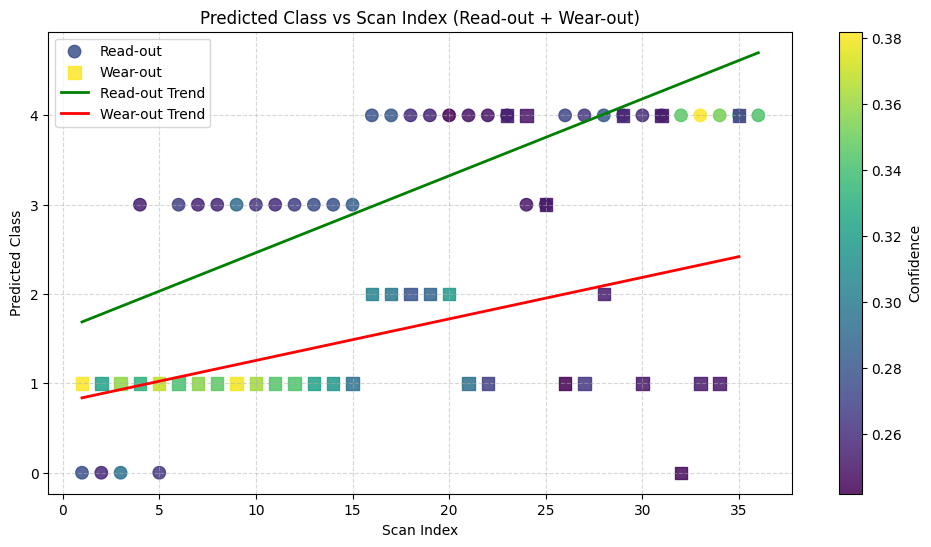

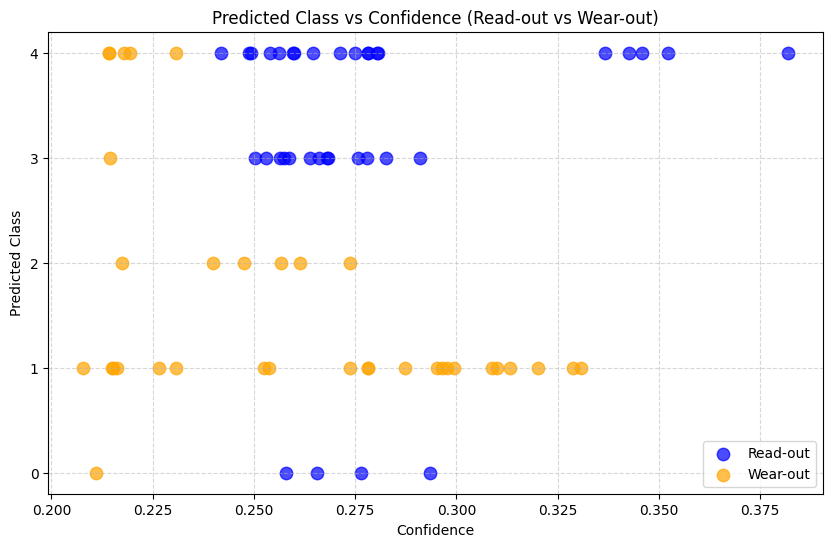

In [ ]:
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = load_trained_model('ibw_reward_model (2).pth', num_classes=5, device=device)

model = load_trained_model('4_perfect.pth', device=device)



transform = transforms.Compose([
    transforms.Resize((86, 86)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Read-out folder predictions ---
file = "exp_data/June 18/read_out/Read_out_0000.ibw"
summarize_ibw_file(file)
read_out_folder = os.path.dirname(file)
read_out_files = sorted([os.path.join(read_out_folder, f) for f in os.listdir(read_out_folder) if f.lower().endswith(".ibw")])

model_metadata_path = "model_training_metadata.pkl"
results_read = predict_with_training_metadata(model, read_out_files, model_metadata_path, device)

# --- Wear-out folder predictions ---
wear_out_folder = read_out_folder.replace("read_out", "wear_out")
wear_out_files = sorted([os.path.join(wear_out_folder, f) for f in os.listdir(wear_out_folder) if f.lower().endswith(".ibw")])
results_wear = predict_with_training_metadata(model, wear_out_files, model_metadata_path, device)

# --- Combine for plotting ---
import matplotlib.pyplot as plt

# Read-out
scan_indices_read = [r.get('scan_index', r.get('scan_index_used', i + 1)) for i, r in enumerate(results_read)]
predicted_classes_read = [r['predicted_class'] for r in results_read]
confidences_read = [r['confidence'] for r in results_read]

# Wear-out (reset scan index to start from 1)
scan_indices_wear = [i + 1 for i in range(len(results_wear))]
predicted_classes_wear = [r['predicted_class'] for r in results_wear]
confidences_wear = [r['confidence'] for r in results_wear]

# Plot both with confidence as color, wear-out as squares, read-out as circles
import numpy as np

plt.figure(figsize=(12, 6))
# Read-out: circles, color by confidence
scatter1 = plt.scatter(
    scan_indices_read, predicted_classes_read, 
    c=confidences_read, cmap='viridis', s=80, alpha=0.85, label='Read-out', marker='o'
)
# Wear-out: squares, color by confidence
scatter2 = plt.scatter(
    scan_indices_wear, predicted_classes_wear, 
    c=confidences_wear, cmap='viridis', s=80, alpha=0.85, label='Wear-out', marker='s'
)

# Add trendline for read-out
z_read = np.polyfit(scan_indices_read, predicted_classes_read, 1)
p_read = np.poly1d(z_read)
plt.plot(scan_indices_read, p_read(scan_indices_read), color='green', linewidth=2, label='Read-out Trend')

# Add trendline for wear-out
z_wear = np.polyfit(scan_indices_wear, predicted_classes_wear, 1)
p_wear = np.poly1d(z_wear)
plt.plot(scan_indices_wear, p_wear(scan_indices_wear), color='red', linewidth=2, label='Wear-out Trend')

plt.xlabel('Scan Index')
plt.ylabel('Predicted Class')
plt.title('Predicted Class vs Scan Index (Read-out + Wear-out)')
plt.yticks(range(5), ['0', '1', '2', '3', '4'])
cbar = plt.colorbar(scatter1, label='Confidence', orientation='vertical')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# --- New plot: Predicted Class vs Confidence, color-coded by dataset ---
plt.figure(figsize=(10, 6))
plt.scatter(confidences_read, predicted_classes_read, c='blue', label='Read-out', alpha=0.7, s=80)
plt.scatter(confidences_wear, predicted_classes_wear, c='orange', label='Wear-out', alpha=0.7, s=80)
plt.xlabel('Confidence')
plt.ylabel('Predicted Class')
plt.title('Predicted Class vs Confidence (Read-out vs Wear-out)')
plt.yticks(range(5), ['0', '1', '2', '3', '4'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename (e.g., _0032)"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def assign_true_class(scan_index, total_files, num_classes=5):
    """Assign true class based on scan index and total number of files (equal splits)"""
    group_size = int(np.ceil(total_files / num_classes))
    return min((scan_index - 1) // group_size, num_classes - 1)

def get_all_ibw_files(folder, recursive=True):
    """Return a list of all .ibw files in a folder (optionally recursive)"""
    ibw_files = []
    if recursive:
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.lower().endswith('.ibw'):
                    ibw_files.append(os.path.join(root, f))
    else:
        ibw_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith('.ibw')]
    return ibw_files

def compute_confusion_matrix_for_folder(folder, model, transform, num_classes=5, title="Confusion Matrix"):
    """
    Reads all .ibw files in a folder, predicts classes, and plots the confusion matrix.
    True classes are assigned by splitting scan indices into five equal groups.
    """
    # 1. Gather all files and scan indices
    ibw_files = get_all_ibw_files(folder)
    if not ibw_files:
        print(f"No .ibw files found in {folder}")
        return None

    scan_indices = [extract_scan_index_from_filename(f) for f in ibw_files]
    # Sort by scan index
    sorted_pairs = sorted(zip(scan_indices, ibw_files), key=lambda x: x[0])
    sorted_scan_indices, sorted_files = zip(*sorted_pairs)
    total_files = len(sorted_files)

    # 2. Assign true classes
    true_classes = [assign_true_class(idx, total_files, num_classes) for idx in sorted_scan_indices]

    # 3. Predict classes
    predicted_classes = []
    for file in sorted_files:
        # --- Replace this with your actual prediction function ---
        # Example: result = predict_single_ibw(model, file, transform, device)
        # predicted_classes.append(result['predicted_class'])
        # For demonstration, use a dummy random prediction:
        # predicted_classes.append(np.random.randint(0, num_classes))
        result = predict_single_ibw(model, file, transform, device='cuda' if torch.cuda.is_available() else 'cpu')
        predicted_classes.append(result['predicted_class'])

    # 4. Compute confusion matrix
    cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(num_classes)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Class {i}" for i in range(num_classes)])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()
    return cm

# Example usage:
model = load_trained_model('ibw_reward_model_5ep.pth', device=device)
transform = transforms.Compose([
    transforms.Resize((86, 86)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
compute_confusion_matrix_for_folder("exp_data/June 18/read_out", model, transform, num_classes=5)

RuntimeError: Error(s) in loading state_dict for RewardAwareModel:
	Unexpected key(s) in state_dict: "classifier.1.running_mean", "classifier.1.running_var", "classifier.1.num_batches_tracked", "reward_predictor.1.running_mean", "reward_predictor.1.running_var", "reward_predictor.1.num_batches_tracked". 

In [ ]:
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as transforms


def predict_from_tensor(model, input_tensor, device, 
                        reward_mean=None, reward_std=None, scan_index=None):
    """
    Predict quality class and reward from a pre-cropped, preprocessed tensor.

    Args:
        model: Trained RewardAwareModel
        input_tensor: torch.Tensor of shape (1, 3, H, W) or (3, H, W)
        device: PyTorch device
        reward_mean: Mean used for reward normalization during training
        reward_std: Std used for reward normalization during training
        scan_index: Optional, for reporting

    Returns:
        dict with prediction results
    """
    model.eval()
    try:
        # Ensure batch dimension
        if input_tensor.ndim == 3:
            input_tensor = input_tensor.unsqueeze(0)
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            class_outputs, reward_outputs = model(input_tensor)
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            predicted_reward_normalized = reward_outputs.item()
            if reward_mean is not None and reward_std is not None and reward_std > 0:
                predicted_reward_original = predicted_reward_normalized * reward_std + reward_mean
            else:
                predicted_reward_original = predicted_reward_normalized

        quality_descriptions = {
            0: "Excellent (Class 0)",
            1: "Good (Class 1)", 
            2: "Fair (Class 2)",
            3: "Poor (Class 3)",
            4: "Bad (Class 4)"
        }

        result = {
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward_normalized': predicted_reward_normalized,
            'predicted_reward_original': predicted_reward_original,
            'scan_index_used': scan_index if scan_index is not None else 0
        }
        return result

    except Exception as e:
        return {
            'error': str(e),
            'predicted_class': None
        }

def crop_center(arr, crop_size):
    """Crop the center region of a 2D numpy array."""
    h, w = arr.shape
    ch = crop_size // 2
    center_row = h // 2
    center_col = w // 2
    return arr[center_row - ch:center_row + ch, center_col - ch:center_col + ch]

def prepare_cropped_channels(ibw_file, crop_size=86, device='cpu'):
    ibw_data = load_ibw(ibw_file)
    ch_names = ibw_data.channels

    # Extract channels
    height_trace = ibw_data.data[ch_names.index('Height (T)')]
    height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
    phase_trace = ibw_data.data[ch_names.index('Phase (T)')]
    phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]

    # Crop each channel (center crop)
    ht_crop = crop_center(height_trace, crop_size)
    hr_crop = crop_center(height_retrace, crop_size)
    pt_crop = crop_center(phase_trace, crop_size)
    pr_crop = crop_center(phase_retrace, crop_size)

    # Convert each crop to PIL Image (normalize to 0-255 for visualization, if needed)
    def to_tensor(arr):
        arr_norm = 255 * (arr - np.min(arr)) / (np.ptp(arr) + 1e-8)
        pil_img = Image.fromarray(arr_norm.astype(np.uint8)).convert("RGB")
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        return transform(pil_img)

    ht_tensor = to_tensor(ht_crop).unsqueeze(0).to(device)
    hr_tensor = to_tensor(hr_crop).unsqueeze(0).to(device)
    pt_tensor = to_tensor(pt_crop).unsqueeze(0).to(device)
    pr_tensor = to_tensor(pr_crop).unsqueeze(0).to(device)

    return {
        'height_trace': ht_tensor,
        'height_retrace': hr_tensor,
        'phase_trace': pt_tensor,
        'phase_retrace': pr_tensor
    }

# Example usage:
ibw_file = "exp_data/June 18/read_out/Read_out_0023.ibw"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cropped_tensors = prepare_cropped_channels(ibw_file, crop_size=86, device=device)

# Set reward_mean and reward_std to None or actual values if available
reward_mean = None
reward_std = None

model = load_trained_model('ibw_reward_model (2).pth', num_classes=5, device=device)


result = predict_from_tensor(
    model,
    cropped_tensors['height_trace'],
    device,
    reward_mean,
    reward_std,
    scan_index=5
)
print(result)

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from ibw_reward_model (2).pth
{'predicted_class': 2, 'quality_description': 'Fair (Class 2)', 'confidence': 0.33655881881713867, 'class_probabilities': array([0.00729538, 0.30616096, 0.33655882, 0.22123852, 0.12874629],
      dtype=float32), 'predicted_reward_normalized': 0.20089663565158844, 'predicted_reward_original': 0.20089663565158844, 'scan_index_used': 5}


## Model trained with 1 epoch appears to rever to binary classifier... not sure if this can be used to our advantage but may want to explore using this to indicate when confidence dips as an indicator about the probabibility the tip is about to break

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

def generate_roc_auc_curve(results, num_classes=5, output_path=None):
    """
    Generate ROC-AUC curves from prediction results
    
    Args:
        results: List of dicts from `predict_single_ibw` or similar
        num_classes: Total number of classes
        output_path: Optional path to save the plot
    
    Returns:
        auc_scores: Dict of AUC scores per class
    """
    y_true = []
    y_probs = []

    for r in results:
        if r.get('predicted_class') is not None:
            y_true.append(r['predicted_class'])
            y_probs.append(r['class_probabilities'])

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # Binarize labels for one-vs-rest ROC computation
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    if output_path:
        plt.savefig(output_path)
        print(f"Saved ROC curve to {output_path}")
    else:
        plt.show()

    return roc_auc


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from ibw_reward_model_5ep.pth
Predicting quality for 36 files...
Processing file 1/36: exp_data/June 18\read_out\Read_out_0000.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.968 confidence
Processing file 2/36: exp_data/June 18\read_out\Read_out_0001.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.971 confidence
Processing file 3/36: exp_data/June 18\read_out\Read_out_0002.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.990 confidence
Processing file 4/36: exp_data/June 18\read_out\Read_out_0003.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.954 confidence
Processing file 5/36: exp_data/June 18\read_out\Read_out_0004.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.890 confidence
Processing file 6/36: exp_data/June 18\read_out\Read_out_0005.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.858 confidence
Processing file 7/36: exp_data/June 18\read_out\Read_out_0006.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.855 confidence
Proce

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


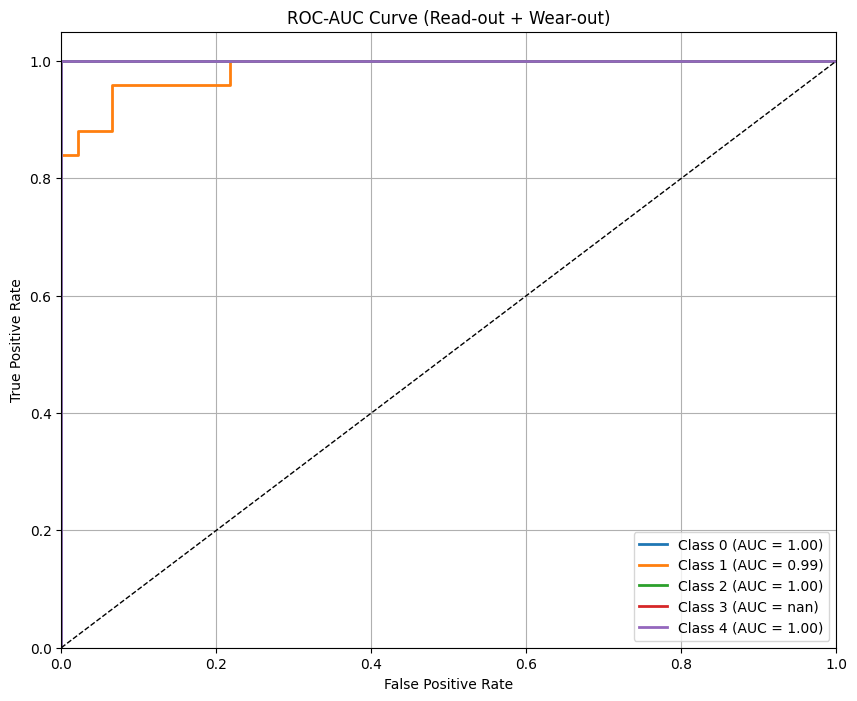


Per-Class AUC Scores:
  Class 0: 1.0000
  Class 1: 0.9852
  Class 2: 1.0000
  Class 3: nan
  Class 4: 1.0000


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchvision import transforms

# --- Assumes all the functions you wrote above are already defined:
# - load_trained_model
# - predict_with_training_metadata
# - etc.

def generate_roc_auc_curve(results, num_classes=5, title="ROC Curve", output_path=None):
    """
    Generate and plot the ROC-AUC curve for multiclass classification.
    """
    y_true = []
    y_probs = []

    for r in results:
        if r.get("predicted_class") is not None:
            y_true.append(r["predicted_class"])
            y_probs.append(r["class_probabilities"])

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # Binarize the output for multiclass ROC
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)

    if output_path:
        plt.savefig(output_path)
        print(f"ROC curve saved to {output_path}")
    else:
        plt.show()

    return roc_auc


if __name__ == "__main__":
    base_folder = "exp_data/June 18"
    model_path = "ibw_reward_model_5ep.pth"
    metadata_path = "model_training_metadata.pkl"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load model
    model = load_trained_model(model_path, device=device)

    # Define transform (if not embedded in metadata, fallback here)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Get .ibw file lists
    read_out_folder = os.path.join(base_folder, "read_out")
    wear_out_folder = os.path.join(base_folder, "wear_out")

    read_out_files = sorted([
        os.path.join(read_out_folder, f) for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f) for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])

    # Predict on both datasets
    results_read = predict_with_training_metadata(model, read_out_files, metadata_path, device)
    results_wear = predict_with_training_metadata(model, wear_out_files, metadata_path, device)

    # Combine results and generate ROC curve
    all_results = results_read + results_wear
    roc_auc = generate_roc_auc_curve(all_results, num_classes=5, title="ROC-AUC Curve (Read-out + Wear-out)")

    print("\nPer-Class AUC Scores:")
    for cls, score in roc_auc.items():
        print(f"  Class {cls}: {score:.4f}")


## Methods to Train
We can now consider various methods to train the ML based on the data that we have. The end goal is to have some model that can take real-time data and make a prediction based off the small sample. This can be done since we are already cropping the images, so assuming that a small piece of information is good enough, we can use this trained model to make predictions before a final image is created.

This requires a bit of interfacing with the actual AFM machine, but from the software standpoint, it can be done in realtime before the next sample cropped image is ready.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aespm.tools as at

file = "exp_data/June 18/read_out/Read_out_0035.ibw"
ibw_data = load_ibw(file)
ch_names = ibw_data.channels
trace = ibw_data.data[ch_names.index('Phase (T)')] 
retrace = ibw_data.data[ch_names.index('Phase (RT)')]
# Plot 10 center lines on the same figure for comparison
plt.figure(figsize=(12, 6))
for i in range(10):
    center_row = 200 + 5*i
    trace_line = trace[center_row, :]
    retrace_line = retrace[center_row, :]
    plt.plot(trace_line, label=f"Trace Row {center_row}", color='blue', alpha=0.5)
    plt.plot(retrace_line, label=f"Retrace Row {center_row}", color='red', linestyle='--', alpha=0.5)

plt.title("Center Line Comparison (Rows 128-137)")
plt.xlabel("Pixel Index")
plt.ylabel("Phase (a.u.)")
# Only show two legend entries for clarity
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend([by_label[l] for l in sorted(set(labels), key=labels.index)][:2], ["Trace", "Retrace"])
plt.grid(True)
plt.tight_layout()
plt.show()

at.display_ibw(file)


NameError: name 'load_ibw' is not defined

## Barlow Twins Approach
Barlow Twins is a self-supervised contrastive learning method. You train a model to learn feature representations without labels using redundancy reduction between views.:

Train the model with Barlow Twins loss
Freeze the encoder
Train a small classifier on top (e.g., linear probe or fine-tune)

Input	Use your height_img crops as different views (augmentations)
Views	Could be 2 random crops/rotations of the same IBW
Encoder	Use ResNet18 trunk (pretrained or not)
Loss	Barlow Twins Loss instead of classification loss
Finetuning	After self-supervised learning, train a classifier with your labeled data

In [ ]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import random

# ----- Barlow Twins Loss -----
class BarlowTwinsLoss(nn.Module):
    def __init__(self, lambda_offdiag=0.0051):
        super().__init__()
        self.lambda_offdiag = lambda_offdiag

    def off_diagonal(self, x):
        n, m = x.shape
        assert n == m
        return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()

    def forward(self, z1, z2):
        N, D = z1.size()
        z1 = (z1 - z1.mean(0)) / z1.std(0)
        z2 = (z2 - z2.mean(0)) / z2.std(0)
        c = (z1.T @ z2) / N
        on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()
        off_diag = self.off_diagonal(c).pow_(2).sum()
        return on_diag + self.lambda_offdiag * off_diag

# ----- Utility to convert AFM height array to PIL ----
def height_to_pil(height_array):
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

# ----- Barlow Twins Dataset -----
class AFMBarlowDataset(Dataset):
    def __init__(self, ibw_data_list, transform=None):
        self.data = ibw_data_list  # List of numpy arrays (256x256)
        self.transform = transform

    def __len__(self):
        return len(self.data) * 9  # 9 crops per image

    def __getitem__(self, idx):
        img_idx = idx // 9
        crop_idx = idx % 9

        height_img = self.data[img_idx]
        pil_img = height_to_pil(height_img)

        crops = self._create_crops(pil_img)
        base_crop = crops[crop_idx]

        # Generate two random augmentations of the same crop
        img1 = self.transform(base_crop)
        img2 = self.transform(base_crop)
        return img1, img2

    def _create_crops(self, img, crop_size=75):
        w, h = img.size
        positions = [0, (w - crop_size) // 2, w - crop_size]
        crops = []
        for y in positions:
            for x in positions:
                crop = img.crop((x, y, x + crop_size, y + crop_size))
                crops.append(crop.resize((224, 224)))
        return crops

# ----- Main Training Loop -----
def train_barlow_twins(model, dataloader, loss_fn, optimizer, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for img1, img2 in dataloader:
            img1, img2 = img1.to(device), img2.to(device)
            z1 = model(img1)
            z2 = model(img2)
            loss = loss_fn(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: Barlow Twins Loss = {total_loss / len(dataloader):.4f}")

# ----- Entrypoint -----
def main():
    import aespm.tools as at  # Make sure this is available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    base_dir = "exp_data/June 18"
    subfolders = ["read_out", "wear_out"]
    ibw_data_list = []

    for folder in subfolders:
        folder_path = os.path.join(base_dir, folder)
        for file in sorted(os.listdir(folder_path)):
            if file.lower().endswith(".ibw"):
                ibw_path = os.path.join(folder_path, file)
                try:
                    ibw = load_ibw(ibw_path)
                    ibw_data_list.append(ibw.z)  # assumes .z is 256x256
                except Exception as e:
                    print(f"Failed to load {ibw_path}: {e}")

    print(f"Loaded {len(ibw_data_list)} IBW height images")

    # Define transforms for self-supervised learning
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])

    dataset = AFMBarlowDataset(ibw_data_list, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

    # Base encoder (ResNet18)
    encoder = models.resnet18(pretrained=False)
    encoder.fc = nn.Identity()
    model = nn.Sequential(encoder).to(device)

    # Train
    loss_fn = BarlowTwinsLoss()
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    train_barlow_twins(model, dataloader, loss_fn, optimizer, device, epochs=50)

    # Save model
    torch.save(model.state_dict(), "barlow_twins_encoder.pth")
    print("Saved encoder to barlow_twins_encoder.pth")

if __name__ == "__main__":
    main()


In [ ]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# ----- Convert height to RGB image -----
def height_to_pil(height_array):
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

# ----- Supervised Dataset using labels -----
class SupervisedAFMDataset(Dataset):
    def __init__(self, ibw_data_list, labels, transform=None):
        self.data = ibw_data_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data) * 9  # 3x3 crops

    def __getitem__(self, idx):
        img_idx = idx // 9
        crop_idx = idx % 9
        height_img = self.data[img_idx]
        label = self.labels[img_idx]
        pil_img = height_to_pil(height_img)
        crop = self._create_crop(pil_img, crop_idx)
        if self.transform:
            crop = self.transform(crop)
        return crop, label

    def _create_crop(self, img, idx, crop_size=75):
        w, h = img.size
        positions = [0, (w - crop_size) // 2, w - crop_size]
        y, x = divmod(idx, 3)
        crop = img.crop((positions[x], positions[y], positions[x] + crop_size, positions[y] + crop_size))
        return crop.resize((224, 224))

# ----- Fine-tune classifier -----
def train_classifier(model, dataloader, optimizer, criterion, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss, correct = 0, 0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
        acc = correct / len(dataloader.dataset)
        print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}, Accuracy = {acc:.4f}")

# ----- Evaluation -----
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
    acc = correct / len(dataloader.dataset)
    print(f"Validation Accuracy: {acc:.4f}")

# ----- Main entry point -----
def main():
    import aespm.tools as at
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    base_dir = "exp_data/June 18"
    subfolders = ["read_out", "wear_out"]
    ibw_data_list = []
    labels = []

    for i, folder in enumerate(subfolders):
        folder_path = os.path.join(base_dir, folder)
        for file in sorted(os.listdir(folder_path)):
            if file.lower().endswith(".ibw"):
                path = os.path.join(folder_path, file)
                try:
                    ibw = load_ibw(path)
                    ibw_data_list.append(ibw.z)
                    labels.append(i)  # 0 for read_out, 1 for wear_out
                except Exception as e:
                    print(f"Error loading {path}: {e}")

    print(f"Loaded {len(ibw_data_list)} images.")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

    dataset = SupervisedAFMDataset(ibw_data_list, labels, transform=transform)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

    # Load the Barlow Twins encoder (wrap in nn.Sequential to match saved state_dict)
    encoder = models.resnet18(pretrained=False)
    encoder.fc = nn.Identity()
    encoder_seq = nn.Sequential(encoder)
    encoder_seq.load_state_dict(torch.load("barlow_twins_encoder.pth", map_location=device))
    encoder_seq.to(device)
    encoder_seq.eval()  # Freeze
    for param in encoder_seq.parameters():
        param.requires_grad = False

    # Add classifier head
    classifier = nn.Sequential(
        encoder_seq,
        nn.Flatten(),
        nn.Linear(512, 2)  # Binary classifier
    ).to(device)

    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    print("Training classifier on top of Barlow Twins features...")
    train_classifier(classifier, train_loader, optimizer, criterion, device, epochs=50)

    print("Evaluating classifier...")
    evaluate(classifier, val_loader, device)

    torch.save(classifier.state_dict(), "barlow_twins_classifier.pth")
    print("Saved full model to barlow_twins_classifier.pth")

if __name__ == "__main__":
    main()


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import torch.nn.functional as F
import traceback


# ----- Convert height to RGB image -----
def height_to_pil(height_array):
    """Convert height numpy array to PIL Image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

# ----- Generate labels based on scan indices (5 classes) -----
def generate_labels_from_scan_indices(scan_indices):
    """
    Generate classification labels based on scan indices.
    Break them into 5 groups based on index to represent tip degradation stages.
    """
    if not scan_indices:
        return []
    
    labels = []
    max_scan = max(scan_indices)
    group_size = max(1, max_scan // 5)  # Ensure group_size is at least 1
    
    for idx in scan_indices:
        # Convert to 0-based, then divide by group_size
        label = min((idx - 1) // group_size, 4)  # Cap at class 4
        labels.append(label)
    
    return labels

# ----- Compute reward function (from your second script) -----
def compute_reward(ibw_data, scan_index=0):
    """
    Compute quality reward for IBW data
    """
    try:
        ch_names = ibw_data.channels
        
        # Extract data
        height_trace = ibw_data.data[ch_names.index('Height (T)')] 
        height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
        phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
        phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
        
        # Extract scan rate
        scan_rate = ibw_data.header.get('ScanRate', 1.0)
        
        rewards = {}
        
        # 1. Height Consistency (Trace vs Retrace)
        min_rows = min(height_trace.shape[0], height_retrace.shape[0])
        if min_rows > 0:
            height_diff = height_trace[:min_rows, :] - height_retrace[:min_rows, :]
            mae_height = np.mean(np.abs(height_diff))
            rewards['height_consistency'] = np.exp(-mae_height / np.std(height_trace))
        else:
            rewards['height_consistency'] = 0.0
        
        # 2. Phase Consistency 
        min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])
        if min_rows_phase > 0:
            phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
            phase_std = np.std(phase_diff)
            phase_range = np.ptp(phase_trace)
            if phase_range > 0:
                normalized_phase_std = phase_std / phase_range
                rewards['phase_consistency'] = np.exp(-5 * normalized_phase_std)
            else:
                rewards['phase_consistency'] = 1.0
        else:
            rewards['phase_consistency'] = 0.0
        
        # 3. Image Sharpness
        height_gradients = np.gradient(height_trace)
        gradient_variance = np.var(height_gradients)
        rewards['sharpness'] = np.tanh(gradient_variance / 1000.0)
        
        # 4. Signal-to-Noise Ratio
        height_signal = np.mean(height_trace)
        height_noise = np.std(height_trace)
        if height_noise > 0:
            snr = abs(height_signal) / height_noise
            rewards['snr'] = np.tanh(snr / 10.0)
        else:
            rewards['snr'] = 1.0
        
        # 5. Data Quality
        height_flat = height_trace.flatten()
        unique_values = len(np.unique(height_flat))
        total_pixels = len(height_flat)
        diversity_ratio = unique_values / total_pixels
        rewards['data_diversity'] = min(diversity_ratio * 10, 1.0)
        
        # 6. Scan Index Penalty (tip freshness)
        max_expected_scans = 35
        rewards['tip_freshness'] = np.exp(-scan_index / max_expected_scans)
        
        # 7. Scan Rate Appropriateness
        optimal_scan_rate = 2.0
        scan_rate_penalty = abs(scan_rate - optimal_scan_rate) / optimal_scan_rate
        rewards['scan_rate'] = np.exp(-scan_rate_penalty)
        
        # Combine rewards with weights
        weights = {
            'height_consistency': 0.2,
            'phase_consistency': 0.2, 
            'sharpness': 0.1,
            'snr': 0.1,
            'data_diversity': 0.1,
            'tip_freshness': 0.2,
            'scan_rate': 0.1
        }
        
        total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
        return total_reward
        
    except Exception as e:
        print(f"Error computing reward: {e}")
        return 0.0

# ----- Enhanced Dataset with multi-class labeling and data augmentation -----
class EnhancedAFMDataset(Dataset):
    def __init__(self, ibw_data_list, scan_indices, compute_rewards=False, transform=None, 
                 use_augmentation=True, crops_per_image=9):
        """
        Enhanced dataset that uses scan indices to generate multi-class labels
        
        Args:
            ibw_data_list: list of loaded IBW data objects
            scan_indices: list of scan indices corresponding to each IBW file
            compute_rewards: whether to compute quality rewards
            transform: torchvision transforms to apply
            use_augmentation: whether to use data augmentation (crops)
            crops_per_image: number of crops per image (default 9 for 3x3 grid)
        """
        self.data = ibw_data_list
        self.scan_indices = scan_indices
        self.transform = transform
        self.use_augmentation = use_augmentation
        self.crops_per_image = crops_per_image
        
        # Generate multi-class labels from scan indices
        self.labels = generate_labels_from_scan_indices(scan_indices)
        
        print(f"Generated {len(self.labels)} labels from scan indices")
        print(f"Label distribution: {np.bincount(self.labels)}")
        
        # Compute rewards if requested
        self.rewards = None
        if compute_rewards:
            print("Computing rewards for all images...")
            self.rewards = []
            for i, data in enumerate(ibw_data_list):
                reward = compute_reward(data, scan_index=scan_indices[i])
                self.rewards.append(reward)
            
            # Normalize rewards
            self.rewards = np.array(self.rewards)
            if len(self.rewards) > 1:
                self.reward_mean = np.mean(self.rewards)
                self.reward_std = np.std(self.rewards)
                if self.reward_std > 0:
                    self.rewards = (self.rewards - self.reward_mean) / self.reward_std
                print(f"Reward normalization: mean={self.reward_mean:.4f}, std={self.reward_std:.4f}")

    def __len__(self):
        if self.use_augmentation:
            return len(self.data) * self.crops_per_image
        else:
            return len(self.data)

    def __getitem__(self, idx):
        try:
            if self.use_augmentation:
                img_idx = idx // self.crops_per_image
                crop_idx = idx % self.crops_per_image
            else:
                img_idx = idx
                crop_idx = 0
            
            # Get height data
            height_img = self.data[img_idx].z
            label = self.labels[img_idx]
            
            # Convert to PIL image
            pil_img = height_to_pil(height_img)
            
            # Create crop if using augmentation
            if self.use_augmentation:
                crop = self._create_crop(pil_img, crop_idx)
            else:
                crop = pil_img.resize((224, 224))
            
            # Apply transforms
            if self.transform:
                crop = self.transform(crop)
            
            result = [crop, label]
            
            # Add reward if computed
            if self.rewards is not None:
                result.append(self.rewards[img_idx])
            
            # Add scan index
            result.append(self.scan_indices[img_idx])
            
            return tuple(result)
            
        except Exception as e:
            print(f"Error in __getitem__ at index {idx}: {e}")
            traceback.print_exc()
            # Return fallback
            dummy_tensor = torch.zeros(3, 224, 224)
            return (dummy_tensor, 0, 0.0, 1)

    def _create_crop(self, img, idx, crop_size=75):
        """Create crop from image using 3x3 grid pattern"""
        w, h = img.size
        positions = [0, (w - crop_size) // 2, w - crop_size]
        y, x = divmod(idx, 3)
        crop = img.crop((positions[x], positions[y], 
                        positions[x] + crop_size, positions[y] + crop_size))
        return crop.resize((224, 224))

# ----- Reward-aware classifier model -----
class BarlowTwinsClassifier(nn.Module):
    def __init__(self, encoder_path, num_classes=5, include_reward_head=False, 
                 freeze_encoder=True, dropout_rate=0.3):
        """
        Classifier built on top of Barlow Twins encoder
        
        Args:
            encoder_path: path to saved Barlow Twins encoder
            num_classes: number of classification classes
            include_reward_head: whether to include reward prediction head
            freeze_encoder: whether to freeze the encoder weights
            dropout_rate: dropout rate for regularization
        """
        super(BarlowTwinsClassifier, self).__init__()
        
        # Load the Barlow Twins encoder
        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()
        
        # Wrap in Sequential to match saved state_dict format
        encoder_seq = nn.Sequential(self.encoder)
        
        # Load pretrained weights
        if os.path.exists(encoder_path):
            print(f"Loading Barlow Twins encoder from {encoder_path}")
            encoder_seq.load_state_dict(torch.load(encoder_path, map_location='cpu'))
        else:
            print(f"Warning: Encoder path {encoder_path} not found, using random initialization")
        
        self.encoder = encoder_seq[0]  # Extract the actual encoder
        
        # Freeze encoder if requested
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
            print("Encoder weights are frozen")
        
        # Get feature dimension
        feature_dim = 512  # ResNet18 feature dimension
        
        # Add dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
        # Optional reward prediction head
        self.include_reward_head = include_reward_head
        if include_reward_head:
            self.reward_predictor = nn.Sequential(
                nn.Linear(feature_dim, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 1)
            )
    
    def forward(self, x, return_features=False):
        # Extract features using the encoder
        features = self.encoder(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction if included
        reward_output = None
        if self.include_reward_head:
            reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            if self.include_reward_head:
                return class_output, reward_output
            else:
                return class_output

# ----- Training function -----
def train_classifier(model, train_loader, val_loader, optimizer, device, 
                    num_epochs=50, use_reward_loss=False, reward_weight=0.1):
    """
    Enhanced training function with optional reward prediction
    """
    classification_criterion = nn.CrossEntropyLoss()
    reward_criterion = nn.MSELoss() if use_reward_loss else None
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_reward_loss = 0.0
        correct = 0
        total = 0
        
        for i, batch_data in enumerate(train_loader):
            # Handle variable batch contents
            if len(batch_data) == 4:  # inputs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
                has_rewards = True
            elif len(batch_data) == 3:  # inputs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                has_rewards = False
            else:
                continue
            
            inputs = inputs.to(device)
            labels = labels.to(device)
            if has_rewards:
                rewards = rewards.to(device)

            if rewards.dtype != torch.float32:
                rewards = rewards.float()

            optimizer.zero_grad()
            
            # Forward pass
            if model.include_reward_head:
                class_outputs, reward_outputs = model(inputs)
            else:
                class_outputs = model(inputs)
                reward_outputs = None
            
            # Compute losses
            class_loss = classification_criterion(class_outputs, labels)
            total_loss = class_loss
            
            if use_reward_loss and reward_outputs is not None and has_rewards:
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                total_loss += reward_weight * reward_loss
                running_reward_loss += reward_loss.item()
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Statistics
            running_loss += total_loss.item()
            running_class_loss += class_loss.item()
            
            _, predicted = torch.max(class_outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Print progress
            if (i + 1) % 50 == 0:
                print(f"  Batch {i+1}/{len(train_loader)}, Loss: {total_loss.item():.4f}")
        
        # Validation phase
        val_loss, val_accuracy = evaluate_classifier(model, val_loader, device, 
                                                   use_reward_loss, reward_weight)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Statistics
        train_accuracy = 100 * correct / total
        avg_train_loss = running_loss / len(train_loader)
        avg_class_loss = running_class_loss / len(train_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}%")
        print(f"  Class Loss: {avg_class_loss:.4f}")
        
        if use_reward_loss and running_reward_loss > 0:
            avg_reward_loss = running_reward_loss / len(train_loader)
            print(f"  Reward Loss: {avg_reward_loss:.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
            }, 'best_barlow_classifier.pth')
            print(f"  Saved best model (Val Loss: {val_loss:.4f})")
        
        print("-" * 60)
    
    return train_losses, val_losses

# ----- Evaluation function -----
def evaluate_classifier(model, dataloader, device, use_reward_loss=False, reward_weight=0.1):
    """Evaluate the classifier and return loss and accuracy"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    classification_criterion = nn.CrossEntropyLoss()
    reward_criterion = nn.MSELoss() if use_reward_loss else None
    
    with torch.no_grad():
        for batch_data in dataloader:
            # Handle variable batch contents
            if len(batch_data) == 4:
                inputs, labels, rewards, scan_indices = batch_data
                has_rewards = True
            elif len(batch_data) == 3:
                inputs, labels, scan_indices = batch_data
                has_rewards = False
            else:
                continue
            
            inputs = inputs.to(device)
            labels = labels.to(device)
            if has_rewards:
                rewards = rewards.to(device)
            
            # Forward pass
            if model.include_reward_head:
                class_outputs, reward_outputs = model(inputs)
            else:
                class_outputs = model(inputs)
                reward_outputs = None
            
            # Compute losses
            class_loss = classification_criterion(class_outputs, labels)
            loss = class_loss
            
            if use_reward_loss and reward_outputs is not None and has_rewards:
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                loss += reward_weight * reward_loss
            
            total_loss += loss.item()
            
            # Accuracy calculation
            _, predicted = torch.max(class_outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Store for detailed metrics
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, accuracy

# ----- Main function -----
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Data loading parameters
    base_dir = "exp_data/June 18"
    subfolders = ["read_out", "wear_out"]
    
    # Load IBW data
    ibw_data_list = []
    scan_indices = []
    
    print("Loading IBW files...")
    for folder in subfolders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(".ibw")])
        print(f"Found {len(files)} IBW files in {folder}")
        
        for i, file in enumerate(files):
            path = os.path.join(folder_path, file)
            try:
                ibw = load_ibw(path)
                ibw_data_list.append(ibw)
                # Extract scan index from filename or use sequential numbering
                scan_idx = i + 1  # You might want to parse this from filename
                scan_indices.append(scan_idx)
            except Exception as e:
                print(f"Error loading {path}: {e}")
    
    print(f"Successfully loaded {len(ibw_data_list)} IBW files")
    
    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Create dataset with multi-class labeling
    dataset = EnhancedAFMDataset(
        ibw_data_list, 
        scan_indices, 
        compute_rewards=True,  # Compute rewards for potential use
        transform=transform,
        use_augmentation=True,
        crops_per_image=9
    )
    
    print(f"Dataset size: {len(dataset)} samples")
    print(f"Augmentation factor: {len(dataset) / len(ibw_data_list):.1f}x")
    
    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Create model
    model = BarlowTwinsClassifier(
        encoder_path="barlow_twins_encoder.pth",
        num_classes=5,  # Multi-class instead of binary
        include_reward_head=True,  # Include reward prediction
        freeze_encoder=True,  # Freeze encoder initially
        dropout_rate=0.3
    )
    model = model.to(device)
    
    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Optimizer - only optimize trainable parameters
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3, 
        weight_decay=1e-4
    )
    
    # Train the classifier
    print("\nStarting training...")
    train_losses, val_losses = train_classifier(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=300,
        use_reward_loss=True,
        reward_weight=0.1
    )
    
    # Final evaluation
    print("\nFinal evaluation on validation set:")
    val_loss, val_accuracy = evaluate_classifier(model, val_loader, device, 
                                                use_reward_loss=True, reward_weight=0.1)
    print(f"Final Validation Loss: {val_loss:.4f}")
    print(f"Final Validation Accuracy: {val_accuracy:.2f}%")
    
    # Detailed classification report
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_data in val_loader:
            if len(batch_data) >= 2:
                inputs, labels = batch_data[0], batch_data[1]
                inputs = inputs.to(device)
                
                if model.include_reward_head:
                    class_outputs, _ = model(inputs)
                else:
                    class_outputs = model(inputs)
                
                _, predicted = torch.max(class_outputs.data, 1)
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
    
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_predictions, 
                              target_names=[f'Class {i}' for i in range(5)]))
    
    # Save final model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_accuracy': val_accuracy,
    }, 'barlow_twins_multiclass_classifier.pth')
    
    print("Training completed! Model saved as 'barlow_twins_multiclass_classifier.pth'")

if __name__ == "__main__":
    main()

Using device: cuda
Loading IBW files...
Found 36 IBW files in read_out
Found 35 IBW files in wear_out
Successfully loaded 71 IBW files
Generated 71 labels from scan indices
Label distribution: [14 14 14 14 15]
Computing rewards for all images...
Reward normalization: mean=0.6319, std=0.0388
Dataset size: 639 samples
Augmentation factor: 9.0x
Training samples: 511
Validation samples: 128
Loading Barlow Twins encoder from barlow_twins_encoder.pth
Encoder weights are frozen


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Total parameters: 11,408,198
Trainable parameters: 231,686

Starting training...
Epoch 1/300
  Train Loss: 1.7145 | Val Loss: 1.6225
  Train Acc: 24.66% | Val Acc: 32.81%
  Class Loss: 1.7145
  Reward Loss: 0.9368
  Saved best model (Val Loss: 1.6225)
------------------------------------------------------------
Epoch 2/300
  Train Loss: 1.5423 | Val Loss: 1.5659
  Train Acc: 35.62% | Val Acc: 34.38%
  Class Loss: 1.5423
  Reward Loss: 0.8319
  Saved best model (Val Loss: 1.5659)
------------------------------------------------------------
Epoch 3/300
  Train Loss: 1.5607 | Val Loss: 1.5071
  Train Acc: 35.81% | Val Acc: 33.59%
  Class Loss: 1.5607
  Reward Loss: 0.8299
  Saved best model (Val Loss: 1.5071)
------------------------------------------------------------
Epoch 4/300
  Train Loss: 1.4863 | Val Loss: 1.4438
  Train Acc: 42.47% | Val Acc: 32.03%
  Class Loss: 1.4863
  Reward Loss: 0.7889
  Saved best model (Val Loss: 1.4438)
----------------------------------------------------

KeyboardInterrupt: 

In [ ]:
!pip install tqdm

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import re
import pandas as pd
from tqdm import tqdm
import json
from datetime import datetime

def height_to_pil(height_array):
    """Convert AFM height array to PIL RGB image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def create_3x3_crops(pil_img, crop_size=75):
    """Create 3x3 crops from PIL image"""
    w, h = pil_img.size
    x_positions = [0, (w - crop_size) // 2, w - crop_size]
    y_positions = [0, (h - crop_size) // 2, h - crop_size]
    crops = []
    for y in y_positions:
        for x in x_positions:
            crop = pil_img.crop((x, y, x + crop_size, y + crop_size)).resize((224, 224))
            crops.append(crop)
    return crops

def predict_single_file(model, transform, ibw_file_path, device='cpu'):
    """Predict on a single IBW file"""
    try:
        # Load IBW file - replace with your actual loading function
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        
        # For now, you'll need to implement your IBW loading here
        # This is a placeholder - replace with your actual loading code
        # import aespm.tools as at
        # ibw_data = at.load_ibw(ibw_file_path)  # Adjust based on your actual function
        # height_img = ibw_data.z
        
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        
        # Convert to PIL and create crops
        pil_img = height_to_pil(height_img)
        crops = create_3x3_crops(pil_img)
        crop_tensors = torch.stack([transform(c) for c in crops], dim=0).to(device)

        # Make predictions
        with torch.no_grad():
            outputs = model(crop_tensors)
            probs = torch.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)  # Average across all crops
            predicted_class = torch.argmax(avg_probs).item()
            confidence = avg_probs[predicted_class].item()
            
            # Calculate prediction consistency (how much crops agree)
            crop_predictions = torch.argmax(probs, dim=1)
            consistency = (crop_predictions == predicted_class).float().mean().item()

        return {
            "file": ibw_file_path,
            "filename": os.path.basename(ibw_file_path),
            "predicted_class": predicted_class,
            "confidence": confidence,
            "consistency": consistency,  # How many crops agreed with final prediction
            "probabilities": avg_probs.cpu().numpy().tolist(),
            "scan_index": scan_index,
            "status": "success"
        }
        
    except Exception as e:
        return {
            "file": ibw_file_path,
            "filename": os.path.basename(ibw_file_path),
            "predicted_class": None,
            "confidence": None,
            "consistency": None,
            "probabilities": None,
            "scan_index": extract_scan_index_from_filename(ibw_file_path),
            "status": "error",
            "error": str(e)
        }

def load_barlow_classifier(model_path, device='cpu'):
    """Load the trained Barlow Twins classifier with encoder and classifier submodules"""
    class BarlowClassifier(nn.Module):
        def __init__(self, num_classes=2):
            super().__init__()
            self.encoder = models.resnet18(pretrained=False)
            self.encoder.fc = nn.Identity()
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(512, num_classes)
            )
        def forward(self, x):
            x = self.encoder(x)
            x = self.classifier(x)
            return x

    # You may need to adjust num_classes if your model is multiclass
    checkpoint = torch.load(model_path, map_location=device)
    # Try to infer num_classes from checkpoint if possible
    num_classes = 2
    for k in checkpoint.keys():
        if k.startswith("classifier.2.weight"):
            num_classes = checkpoint[k].shape[0]
            break
        if k.startswith("classifier.1.weight"):
            num_classes = checkpoint[k].shape[0]
            break
        if k.startswith("classifier.4.weight"):
            num_classes = checkpoint[k].shape[0]
            break
    model = BarlowClassifier(num_classes=num_classes)
    # If checkpoint is wrapped in dict
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    # Remove any 'module.' prefix if present (from DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            k = k[len("module.") :]
        new_state_dict[k] = v

    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)
    model.eval()
    return model

def batch_predict_folder(model_path, data_folder, output_dir="predictions", device='cpu'):
    """
    Run predictions on all IBW files in a folder structure
    
    Args:
        model_path: Path to the trained model
        data_folder: Root folder containing IBW files (can have subfolders)
        output_dir: Directory to save results
        device: Device to run on ('cpu' or 'cuda')
    """
    
    print(f"Starting batch prediction on folder: {data_folder}")
    print(f"Using device: {device}")
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Load model
    print("Loading model...")
    model = load_barlow_classifier(model_path, device)
    
    # Setup transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
    
    # Find all IBW files
    ibw_files = []
    for root, dirs, files in os.walk(data_folder):
        for file in files:
            if file.lower().endswith('.ibw'):
                ibw_files.append(os.path.join(root, file))
    
    print(f"Found {len(ibw_files)} IBW files")
    
    if len(ibw_files) == 0:
        print("No IBW files found!")
        return
    
    # Process files
    results = []
    label_map = {0: "Read Out (Tip Good)", 1: "Wear Out (Tip Worn)"}
    
    print("Processing files...")
    for ibw_file in tqdm(ibw_files, desc="Predicting"):
        result = predict_single_file(model, transform, ibw_file, device)
        
        # Add human-readable label
        if result["predicted_class"] is not None:
            result["label"] = label_map[result["predicted_class"]]
        else:
            result["label"] = "Error"
            
        # Add relative path for easier reading
        result["relative_path"] = os.path.relpath(ibw_file, data_folder)
        
        results.append(result)
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save as CSV
    df = pd.DataFrame(results)
    csv_path = os.path.join(output_dir, f"predictions_{timestamp}.csv")
    df.to_csv(csv_path, index=False)
    print(f"Results saved to: {csv_path}")
    
    # Save as JSON (more detailed)
    json_path = os.path.join(output_dir, f"predictions_detailed_{timestamp}.json")
    with open(json_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Detailed results saved to: {json_path}")
    
    # Print summary statistics
    successful_predictions = [r for r in results if r["status"] == "success"]
    failed_predictions = [r for r in results if r["status"] == "error"]
    
    print(f"\n=== PREDICTION SUMMARY ===")
    print(f"Total files processed: {len(results)}")
    print(f"Successful predictions: {len(successful_predictions)}")
    print(f"Failed predictions: {len(failed_predictions)}")
    
    if successful_predictions:
        # Class distribution
        class_counts = {}
        confidence_scores = []
        consistency_scores = []
        
        for result in successful_predictions:
            label = result["label"]
            class_counts[label] = class_counts.get(label, 0) + 1
            confidence_scores.append(result["confidence"])
            consistency_scores.append(result["consistency"])
        
        print(f"\nClass Distribution:")
        for label, count in class_counts.items():
            percentage = (count / len(successful_predictions)) * 100
            print(f"  {label}: {count} files ({percentage:.1f}%)")
        
        print(f"\nAverage Confidence: {np.mean(confidence_scores):.3f} ± {np.std(confidence_scores):.3f}")
        print(f"Average Consistency: {np.mean(consistency_scores):.3f} ± {np.std(consistency_scores):.3f}")
    
    if failed_predictions:
        print(f"\nFailed files:")
        for result in failed_predictions:
            print(f"  {result['filename']}: {result['error']}")
    
    return results, csv_path, json_path

def predict_specific_subfolders(model_path, base_folder, subfolders=None, output_dir="predictions", device='cpu'):
    """
    Run predictions on specific subfolders (like your read_out and wear_out folders)
    
    Args:
        model_path: Path to trained model
        base_folder: Base directory (e.g., "exp_data/June 18")
        subfolders: List of subfolder names (e.g., ["read_out", "wear_out"])
        output_dir: Output directory
        device: Device to use
    """
    
    if subfolders is None:
        subfolders = ["read_out", "wear_out"]
    
    all_results = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        print(f"\n=== Processing {subfolder} folder ===")
        
        # Get IBW files in this subfolder
        ibw_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.ibw')]
        
        if not ibw_files:
            print(f"No IBW files found in {folder_path}")
            continue
        
        # Run predictions on this subfolder
        results, _, _ = batch_predict_folder(
            model_path, 
            folder_path, 
            output_dir=os.path.join(output_dir, subfolder),
            device=device
        )
        
        # Add ground truth labels for evaluation
        ground_truth_label = 0 if subfolder == "read_out" else 1
        for result in results:
            result["ground_truth_class"] = ground_truth_label
            result["ground_truth_label"] = "Read Out (Tip Good)" if ground_truth_label == 0 else "Wear Out (Tip Worn)"
            result["correct_prediction"] = result["predicted_class"] == ground_truth_label if result["predicted_class"] is not None else None
        
        all_results.extend(results)
    
    # Calculate overall accuracy
    successful_results = [r for r in all_results if r["status"] == "success"]
    if successful_results:
        correct_predictions = sum(1 for r in successful_results if r["correct_prediction"])
        accuracy = correct_predictions / len(successful_results)
        print(f"\n=== OVERALL ACCURACY ===")
        print(f"Accuracy: {accuracy:.3f} ({correct_predictions}/{len(successful_results)})")
        
        # Confusion matrix
        true_positives = sum(1 for r in successful_results 
                           if r["ground_truth_class"] == 1 and r["predicted_class"] == 1)
        false_positives = sum(1 for r in successful_results 
                            if r["ground_truth_class"] == 0 and r["predicted_class"] == 1)
        true_negatives = sum(1 for r in successful_results 
                           if r["ground_truth_class"] == 0 and r["predicted_class"] == 0)
        false_negatives = sum(1 for r in successful_results 
                            if r["ground_truth_class"] == 1 and r["predicted_class"] == 0)
        
        print(f"\nConfusion Matrix:")
        print(f"True Positives (Wear Out correctly identified): {true_positives}")
        print(f"False Positives (Read Out misclassified as Wear Out): {false_positives}")
        print(f"True Negatives (Read Out correctly identified): {true_negatives}")
        print(f"False Negatives (Wear Out misclassified as Read Out): {false_negatives}")
        
        if true_positives + false_negatives > 0:
            sensitivity = true_positives / (true_positives + false_negatives)
            print(f"Sensitivity (Recall for Wear Out): {sensitivity:.3f}")
        
        if true_negatives + false_positives > 0:
            specificity = true_negatives / (true_negatives + false_positives)
            print(f"Specificity (Recall for Read Out): {specificity:.3f}")
    
    return all_results

# Example usage
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Option 1: Process entire folder recursively
    # results, csv_path, json_path = batch_predict_folder(
    #     model_path="barlow_twins_classifier.pth",
    #     data_folder="exp_data/June 18",
    #     output_dir="prediction_results",
    #     device=device
    # )
    
    # Option 2: Process specific subfolders with ground truth evaluation
    results = predict_specific_subfolders(
        model_path="barlow_twins_classifier.pth",
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="prediction_results",
        device=device
    )
    
    print("\nBatch prediction completed!")

In [ ]:
!pip install seaborn

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import re
import pandas as pd
from tqdm import tqdm
import json
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report
import seaborn as sns

def height_to_pil(height_array):
    """Convert AFM height array to PIL RGB image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def create_3x3_crops(pil_img, crop_size=75):
    """Create 3x3 crops from PIL image"""
    w, h = pil_img.size
    x_positions = [0, (w - crop_size) // 2, w - crop_size]
    y_positions = [0, (h - crop_size) // 2, h - crop_size]
    crops = []
    for y in y_positions:
        for x in x_positions:
            crop = pil_img.crop((x, y, x + crop_size, y + crop_size)).resize((224, 224))
            crops.append(crop)
    return crops

class BarlowBinaryClassifier(nn.Module):
    """Binary classifier matching your model structure"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

def load_binary_classifier(model_path, device='cpu'):
    """Load the trained binary Barlow Twins classifier"""
    checkpoint = torch.load(model_path, map_location=device)
    
    # Try to infer num_classes from checkpoint
    num_classes = 2
    state_dict = checkpoint if not isinstance(checkpoint, dict) else checkpoint.get("model_state_dict", checkpoint)
    
    for k in state_dict.keys():
        if k.startswith("classifier.1.weight") or k.startswith("classifier.2.weight"):
            num_classes = state_dict[k].shape[0]
            break
    
    model = BarlowBinaryClassifier(num_classes=num_classes)
    
    # Remove any 'module.' prefix if present (from DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            k = k[len("module."):]
        new_state_dict[k] = v
    
    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)
    model.eval()
    
    return model

def predict_with_probabilities_binary(model, transform, ibw_file_path, device='cpu'):
    """Predict on a single IBW file and return class probabilities for binary classification"""
    try:
        # Load IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        
        # Convert to PIL and create crops
        pil_img = height_to_pil(height_img)
        crops = create_3x3_crops(pil_img)
        crop_tensors = torch.stack([transform(c) for c in crops], dim=0).to(device)

        # Make predictions
        with torch.no_grad():
            outputs = model(crop_tensors)
            probs = torch.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)  # Average across all crops

        return {
            "file": ibw_file_path,
            "probabilities": avg_probs.cpu().numpy(),
            "scan_index": scan_index,
            "status": "success"
        }
        
    except Exception as e:
        return {
            "file": ibw_file_path,
            "probabilities": None,
            "scan_index": extract_scan_index_from_filename(ibw_file_path),
            "status": "error",
            "error": str(e)
        }

def generate_binary_ground_truth_labels(files_data, subfolder_name):
    """Generate ground truth labels for binary classification"""
    labels = []
    
    for data in files_data:
        if subfolder_name == "read_out":
            gt_label = 0  # Good tip
        else:  # wear_out
            gt_label = 1  # Worn tip
        
        labels.append(gt_label)
    
    return labels

def collect_binary_prediction_data(model_path, base_folder, subfolders=None, device='cpu'):
    """Collect prediction probabilities and ground truth labels for binary ROC analysis"""
    
    if subfolders is None:
        subfolders = ["read_out", "wear_out"]
    
    print(f"Collecting binary prediction data for ROC analysis...")
    print(f"Using device: {device}")
    
    # Load model
    model = load_binary_classifier(model_path, device)
    
    # Setup transform - using the same normalization as your batch prediction
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
    
    all_probabilities = []
    all_labels = []
    all_file_info = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        print(f"Processing {subfolder} folder...")
        
        # Get IBW files
        ibw_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                    if f.lower().endswith('.ibw')]
        
        if not ibw_files:
            print(f"No IBW files found in {folder_path}")
            continue
        
        # Collect predictions
        subfolder_data = []
        for ibw_file in tqdm(ibw_files, desc=f"Processing {subfolder}"):
            result = predict_with_probabilities_binary(model, transform, ibw_file, device)
            if result["status"] == "success":
                subfolder_data.append(result)
        
        # Generate ground truth labels for this subfolder
        gt_labels = generate_binary_ground_truth_labels(subfolder_data, subfolder)
        
        # Collect data
        for i, data in enumerate(subfolder_data):
            all_probabilities.append(data["probabilities"])
            all_labels.append(gt_labels[i])
            all_file_info.append({
                "file": data["file"],
                "subfolder": subfolder,
                "scan_index": data["scan_index"],
                "ground_truth": gt_labels[i]
            })
    
    return np.array(all_probabilities), np.array(all_labels), all_file_info

def plot_binary_roc_curve(y_true, y_probs, output_dir="roc_analysis"):
    """Generate and save ROC curve for binary classification"""
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Get probabilities for positive class (class 1 - worn tip)
    y_scores = y_probs[:, 1]
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve for Binary Tool Wear Classification\n(Tip Good vs Tip Worn)', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'binary_roc_curve_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return roc_auc

def plot_precision_recall_curve(y_true, y_probs, output_dir="roc_analysis"):
    """Generate and save Precision-Recall curve"""
    
    # Get probabilities for positive class (class 1 - worn tip)
    y_scores = y_probs[:, 1]
    
    # Compute Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)
    
    # Plot PR curve
    plt.figure(figsize=(10, 8))
    plt.plot(recall, precision, color='blue', lw=2,
             label=f'Precision-Recall curve (AP = {avg_precision:.3f})')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve for Binary Tool Wear Classification', fontsize=14)
    plt.legend(loc="lower left", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add baseline (random classifier performance)
    baseline = np.sum(y_true) / len(y_true)
    plt.axhline(y=baseline, color='red', linestyle='--', 
                label=f'Random Classifier (AP = {baseline:.3f})')
    plt.legend(loc="lower left", fontsize=12)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'precision_recall_curve_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return avg_precision

def plot_binary_confusion_matrix(y_true, y_pred, output_dir="roc_analysis"):
    """Generate a confusion matrix heatmap for binary classification"""
    
    class_names = ["Tip Good (Read Out)", "Tip Worn (Wear Out)"]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Binary Tool Wear Classification', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'binary_confusion_matrix_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return cm

def plot_probability_distributions(y_true, y_probs, output_dir="roc_analysis"):
    """Plot probability distributions for each class"""
    
    # Get probabilities for positive class (class 1 - worn tip)
    y_scores = y_probs[:, 1]
    
    plt.figure(figsize=(12, 6))
    
    # Plot distributions
    good_tips = y_scores[y_true == 0]
    worn_tips = y_scores[y_true == 1]
    
    plt.subplot(1, 2, 1)
    plt.hist(good_tips, bins=30, alpha=0.7, color='green', label='Tip Good', density=True)
    plt.hist(worn_tips, bins=30, alpha=0.7, color='red', label='Tip Worn', density=True)
    plt.xlabel('Probability of "Tip Worn"')
    plt.ylabel('Density')
    plt.title('Probability Distributions by True Class')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Box plot
    plt.subplot(1, 2, 2)
    data_to_plot = [good_tips, worn_tips]
    labels = ['Tip Good', 'Tip Worn']
    bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    plt.ylabel('Probability of "Tip Worn"')
    plt.title('Probability Distribution Box Plot')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'probability_distributions_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def calculate_optimal_threshold(y_true, y_probs):
    """Calculate optimal threshold using Youden's J statistic"""
    
    y_scores = y_probs[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Youden's J statistic = TPR - FPR
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    return optimal_threshold, j_scores[optimal_idx]

def run_complete_binary_roc_analysis(model_path, base_folder, subfolders=None, 
                                   output_dir="roc_analysis", device='cpu'):
    """Run complete ROC analysis for binary classification"""
    
    print("=== STARTING BINARY ROC ANALYSIS ===")
    
    # Collect prediction data
    y_probs, y_true, file_info = collect_binary_prediction_data(
        model_path, base_folder, subfolders, device
    )
    
    if len(y_true) == 0:
        print("No valid prediction data found. Cannot generate ROC curves.")
        return
    
    print(f"Collected {len(y_true)} predictions for ROC analysis")
    
    # Generate predicted classes
    y_pred = np.argmax(y_probs, axis=1)
    
    # Calculate metrics
    accuracy = np.mean(y_true == y_pred)
    roc_auc = roc_auc_score(y_true, y_probs[:, 1])
    
    print(f"Overall Accuracy: {accuracy:.3f}")
    print(f"ROC AUC Score: {roc_auc:.3f}")
    
    # Find optimal threshold
    optimal_threshold, j_statistic = calculate_optimal_threshold(y_true, y_probs)
    print(f"Optimal Threshold (Youden's J): {optimal_threshold:.3f}")
    print(f"J Statistic: {j_statistic:.3f}")
    
    # Generate plots
    print("Generating ROC curve...")
    plot_binary_roc_curve(y_true, y_probs, output_dir)
    
    print("Generating Precision-Recall curve...")
    avg_precision = plot_precision_recall_curve(y_true, y_probs, output_dir)
    
    print("Generating confusion matrix...")
    cm = plot_binary_confusion_matrix(y_true, y_pred, output_dir)
    
    print("Generating probability distributions...")
    plot_probability_distributions(y_true, y_probs, output_dir)
    
    # Calculate detailed metrics
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
    
    # Save detailed results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create detailed results dataframe
    detailed_results = []
    for i, info in enumerate(file_info):
        result = {
            'file': info['file'],
            'subfolder': info['subfolder'],
            'scan_index': info['scan_index'],
            'ground_truth': y_true[i],
            'predicted': y_pred[i],
            'correct': y_true[i] == y_pred[i],
            'prob_tip_good': y_probs[i][0],
            'prob_tip_worn': y_probs[i][1],
            'confidence': y_probs[i][y_pred[i]]
        }
        detailed_results.append(result)
    
    results_df = pd.DataFrame(detailed_results)
    results_df.to_csv(os.path.join(output_dir, f'detailed_binary_roc_results_{timestamp}.csv'), index=False)
    
    # Create summary dataframe
    summary_metrics = {
        'Metric': ['Accuracy', 'ROC AUC', 'Average Precision', 'Sensitivity (Recall)', 
                   'Specificity', 'Precision', 'Negative Predictive Value', 
                   'True Positives', 'True Negatives', 'False Positives', 'False Negatives',
                   'Optimal Threshold', 'Youden J Statistic'],
        'Value': [accuracy, roc_auc, avg_precision, sensitivity, specificity, precision, npv,
                  tp, tn, fp, fn, optimal_threshold, j_statistic]
    }
    
    summary_df = pd.DataFrame(summary_metrics)
    summary_df.to_csv(os.path.join(output_dir, f'binary_roc_summary_{timestamp}.csv'), index=False)
    
    # Generate classification report
    class_names = ["Tip Good", "Tip Worn"]
    class_report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    print(f"\n=== BINARY ROC ANALYSIS SUMMARY ===")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"ROC AUC: {roc_auc:.3f}")
    print(f"Average Precision: {avg_precision:.3f}")
    print(f"Sensitivity (Recall for Tip Worn): {sensitivity:.3f}")
    print(f"Specificity (Recall for Tip Good): {specificity:.3f}")
    print(f"Precision (for Tip Worn): {precision:.3f}")
    print(f"Negative Predictive Value: {npv:.3f}")
    print(f"\nConfusion Matrix:")
    print(f"True Negatives (Tip Good correctly identified): {tn}")
    print(f"False Positives (Tip Good misclassified as Worn): {fp}")
    print(f"False Negatives (Tip Worn misclassified as Good): {fn}")
    print(f"True Positives (Tip Worn correctly identified): {tp}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    print(f"\nResults saved to: {output_dir}")
    
    return {
        'roc_auc': roc_auc,
        'accuracy': accuracy,
        'average_precision': avg_precision,
        'summary_df': summary_df,
        'detailed_results': results_df,
        'confusion_matrix': cm,
        'optimal_threshold': optimal_threshold
    }

# Example usage
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Run complete binary ROC analysis
    results = run_complete_binary_roc_analysis(
        model_path="barlow_twins_classifier.pth",
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="binary_roc_analysis",
        device=device
    )
    
    print("\nBinary ROC analysis completed!")

In [ ]:
!pip install tqdm

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import re
import pandas as pd
from tqdm import tqdm
import json
from datetime import datetime

def height_to_pil(height_array):
    """Convert AFM height array to PIL RGB image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def create_3x3_crops(pil_img, crop_size=75):
    """Create 3x3 crops from PIL image"""
    w, h = pil_img.size
    x_positions = [0, (w - crop_size) // 2, w - crop_size]
    y_positions = [0, (h - crop_size) // 2, h - crop_size]
    crops = []
    for y in y_positions:
        for x in x_positions:
            crop = pil_img.crop((x, y, x + crop_size, y + crop_size)).resize((224, 224))
            crops.append(crop)
    return crops

def predict_single_file(model, transform, ibw_file_path, device='cpu'):
    """Predict on a single IBW file"""
    try:
        # Load IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        
        # Convert to PIL and create crops
        pil_img = height_to_pil(height_img)
        crops = create_3x3_crops(pil_img)
        crop_tensors = torch.stack([transform(c) for c in crops], dim=0).to(device)

        # Make predictions
        with torch.no_grad():
            if model.include_reward_head:
                outputs, reward_outputs = model(crop_tensors)
                # Average reward predictions across crops
                avg_reward = reward_outputs.mean().item()
            else:
                outputs = model(crop_tensors)
                avg_reward = None
                
            probs = torch.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)  # Average across all crops
            predicted_class = torch.argmax(avg_probs).item()
            confidence = avg_probs[predicted_class].item()
            
            # Calculate prediction consistency (how much crops agree)
            crop_predictions = torch.argmax(probs, dim=1)
            consistency = (crop_predictions == predicted_class).float().mean().item()

        return {
            "file": ibw_file_path,
            "filename": os.path.basename(ibw_file_path),
            "predicted_class": predicted_class,
            "confidence": confidence,
            "consistency": consistency,  # How many crops agreed with final prediction
            "probabilities": avg_probs.cpu().numpy().tolist(),
            "predicted_reward": avg_reward,
            "scan_index": scan_index,
            "status": "success"
        }
        
    except Exception as e:
        return {
            "file": ibw_file_path,
            "filename": os.path.basename(ibw_file_path),
            "predicted_class": None,
            "confidence": None,
            "consistency": None,
            "probabilities": None,
            "predicted_reward": None,
            "scan_index": extract_scan_index_from_filename(ibw_file_path),
            "status": "error",
            "error": str(e)
        }

class BarlowTwinsClassifier(nn.Module):
    def __init__(self, num_classes=5, include_reward_head=True, dropout_rate=0.3):
        """
        Classifier built on top of Barlow Twins encoder
        Must match the architecture from your training script
        """
        super(BarlowTwinsClassifier, self).__init__()
        
        # Encoder (ResNet18)
        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()
        
        # Get feature dimension
        feature_dim = 512  # ResNet18 feature dimension
        
        # Add dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head - matches your training script exactly
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
        # Optional reward prediction head
        self.include_reward_head = include_reward_head
        if include_reward_head:
            self.reward_predictor = nn.Sequential(
                nn.Linear(feature_dim, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 1)
            )
    
    def forward(self, x, return_features=False):
        # Extract features using the encoder
        features = self.encoder(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction if included
        reward_output = None
        if self.include_reward_head:
            reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            if self.include_reward_head:
                return class_output, reward_output
            else:
                return class_output

def load_multiclass_classifier(model_path, device='cpu', num_classes=5):
    """Load the trained multiclass classifier"""
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Determine if model has reward head by examining state dict
    has_reward_head = any(k.startswith("reward_predictor") for k in checkpoint['model_state_dict'].keys())
    
    # Create model with same architecture as training
    model = BarlowTwinsClassifier(
        num_classes=num_classes, 
        include_reward_head=has_reward_head,
        dropout_rate=0.3
    )
    
    # Load state dict
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    model.to(device)
    model.eval()
    
    print(f"Loaded model with {num_classes} classes, reward head: {has_reward_head}")
    
    return model

def batch_predict_folder(model_path, data_folder, output_dir="predictions", device='cpu', num_classes=5):
    """
    Run predictions on all IBW files in a folder structure
    
    Args:
        model_path: Path to the trained model
        data_folder: Root folder containing IBW files (can have subfolders)
        output_dir: Directory to save results
        device: Device to run on ('cpu' or 'cuda')
        num_classes: Number of classes in the model
    """
    
    print(f"Starting batch prediction on folder: {data_folder}")
    print(f"Using device: {device}")
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Load model
    print("Loading model...")
    model = load_multiclass_classifier(model_path, device, num_classes)
    
    # Setup transform - matches your training script
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Find all IBW files
    ibw_files = []
    for root, dirs, files in os.walk(data_folder):
        for file in files:
            if file.lower().endswith('.ibw'):
                ibw_files.append(os.path.join(root, file))
    
    print(f"Found {len(ibw_files)} IBW files")
    
    if len(ibw_files) == 0:
        print("No IBW files found!")
        return
    
    # Process files
    results = []
    # Define class labels for 5-class system
    label_map = {
        0: "Fresh Tip (Class 0)",
        1: "Slight Wear (Class 1)", 
        2: "Moderate Wear (Class 2)",
        3: "Significant Wear (Class 3)",
        4: "Heavily Worn (Class 4)"
    }
    
    print("Processing files...")
    for ibw_file in tqdm(ibw_files, desc="Predicting"):
        result = predict_single_file(model, transform, ibw_file, device)
        
        # Add human-readable label
        if result["predicted_class"] is not None:
            result["label"] = label_map[result["predicted_class"]]
        else:
            result["label"] = "Error"
            
        # Add relative path for easier reading
        result["relative_path"] = os.path.relpath(ibw_file, data_folder)
        
        results.append(result)
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save as CSV
    df = pd.DataFrame(results)
    csv_path = os.path.join(output_dir, f"multiclass_predictions_{timestamp}.csv")
    df.to_csv(csv_path, index=False)
    print(f"Results saved to: {csv_path}")
    
    # Save as JSON (more detailed)
    json_path = os.path.join(output_dir, f"multiclass_predictions_detailed_{timestamp}.json")
    with open(json_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Detailed results saved to: {json_path}")
    
    # Print summary statistics
    successful_predictions = [r for r in results if r["status"] == "success"]
    failed_predictions = [r for r in results if r["status"] == "error"]
    
    print(f"\n=== PREDICTION SUMMARY ===")
    print(f"Total files processed: {len(results)}")
    print(f"Successful predictions: {len(successful_predictions)}")
    print(f"Failed predictions: {len(failed_predictions)}")
    
    if successful_predictions:
        # Class distribution
        class_counts = {}
        confidence_scores = []
        consistency_scores = []
        reward_scores = []
        
        for result in successful_predictions:
            label = result["label"]
            class_counts[label] = class_counts.get(label, 0) + 1
            confidence_scores.append(result["confidence"])
            consistency_scores.append(result["consistency"])
            if result["predicted_reward"] is not None:
                reward_scores.append(result["predicted_reward"])
        
        print(f"\nClass Distribution:")
        for label, count in class_counts.items():
            percentage = (count / len(successful_predictions)) * 100
            print(f"  {label}: {count} files ({percentage:.1f}%)")
        
        print(f"\nAverage Confidence: {np.mean(confidence_scores):.3f} ± {np.std(confidence_scores):.3f}")
        print(f"Average Consistency: {np.mean(consistency_scores):.3f} ± {np.std(consistency_scores):.3f}")
        
        if reward_scores:
            print(f"Average Predicted Reward: {np.mean(reward_scores):.3f} ± {np.std(reward_scores):.3f}")
    
    if failed_predictions:
        print(f"\nFailed files:")
        for result in failed_predictions:
            print(f"  {result['filename']}: {result['error']}")
    
    return results, csv_path, json_path

def generate_ground_truth_labels(scan_indices, num_classes=5):
    """Generate ground truth labels from scan indices for evaluation"""
    if not scan_indices:
        return []
    
    labels = []
    max_scan = max(scan_indices)
    group_size = max(1, max_scan // num_classes)
    
    for idx in scan_indices:
        label = min((idx - 1) // group_size, num_classes - 1)
        labels.append(label)
    
    return labels

def predict_specific_subfolders(model_path, base_folder, subfolders=None, output_dir="predictions", 
                               device='cpu', num_classes=5):
    """
    Run predictions on specific subfolders with ground truth evaluation
    
    Args:
        model_path: Path to trained model
        base_folder: Base directory (e.g., "exp_data/June 18")
        subfolders: List of subfolder names (e.g., ["read_out", "wear_out"])
        output_dir: Output directory
        device: Device to use
        num_classes: Number of classes in model
    """
    
    if subfolders is None:
        subfolders = ["read_out", "wear_out"]
    
    all_results = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        print(f"\n=== Processing {subfolder} folder ===")
        
        # Get IBW files in this subfolder
        ibw_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.ibw')]
        
        if not ibw_files:
            print(f"No IBW files found in {folder_path}")
            continue
        
        # Run predictions on this subfolder
        results, _, _ = batch_predict_folder(
            model_path, 
            folder_path, 
            output_dir=os.path.join(output_dir, subfolder),
            device=device,
            num_classes=num_classes
        )
        
        # Add ground truth labels based on scan indices for multiclass evaluation
        for result in results:
            if result["status"] == "success":
                scan_idx = result["scan_index"]
                # Generate ground truth label from scan index (same logic as training)
                if subfolder == "read_out":
                    # Early scans should be class 0-1 (fresh tips)
                    gt_label = min(scan_idx // 10, 1)  # Adjust this logic as needed
                else:  # wear_out
                    # Later scans should be class 3-4 (worn tips)
                    gt_label = min(3 + scan_idx // 15, 4)  # Adjust this logic as needed
                
                result["ground_truth_class"] = gt_label
                result["ground_truth_label"] = f"Ground Truth Class {gt_label}"
                result["correct_prediction"] = result["predicted_class"] == gt_label
        
        all_results.extend(results)
    
    # Calculate overall accuracy and detailed metrics
    successful_results = [r for r in all_results if r["status"] == "success" and "ground_truth_class" in r]
    if successful_results:
        correct_predictions = sum(1 for r in successful_results if r["correct_prediction"])
        accuracy = correct_predictions / len(successful_results)
        print(f"\n=== OVERALL ACCURACY ===")
        print(f"Accuracy: {accuracy:.3f} ({correct_predictions}/{len(successful_results)})")
        
        # Detailed classification metrics
        from collections import defaultdict
        confusion_matrix = defaultdict(lambda: defaultdict(int))
        
        for result in successful_results:
            gt = result["ground_truth_class"]
            pred = result["predicted_class"]
            confusion_matrix[gt][pred] += 1
        
        print(f"\nConfusion Matrix:")
        print("GT\\Pred", end="")
        for pred_class in range(num_classes):
            print(f"\tC{pred_class}", end="")
        print()
        
        for gt_class in range(num_classes):
            print(f"C{gt_class}", end="")
            for pred_class in range(num_classes):
                count = confusion_matrix[gt_class][pred_class]
                print(f"\t{count}", end="")
            print()
        
        # Per-class metrics
        print(f"\nPer-class Metrics:")
        for class_idx in range(num_classes):
            # Calculate precision, recall, F1 for each class
            tp = confusion_matrix[class_idx][class_idx]
            fp = sum(confusion_matrix[other_class][class_idx] 
                    for other_class in range(num_classes) if other_class != class_idx)
            fn = sum(confusion_matrix[class_idx][other_class] 
                    for other_class in range(num_classes) if other_class != class_idx)
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"  Class {class_idx}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")
    
    # Save combined results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    combined_csv = os.path.join(output_dir, f"combined_evaluation_{timestamp}.csv")
    df_combined = pd.DataFrame(all_results)
    df_combined.to_csv(combined_csv, index=False)
    print(f"\nCombined results saved to: {combined_csv}")
    
    return all_results

# Example usage
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Option 1: Process entire folder recursively
    # results, csv_path, json_path = batch_predict_folder(
    #     model_path="barlow_twins_multiclass_classifier.pth",  # Updated model name
    #     data_folder="exp_data/June 18",
    #     output_dir="multiclass_prediction_results",
    #     device=device,
    #     num_classes=5
    # )
    
    # Option 2: Process specific subfolders with ground truth evaluation
    results = predict_specific_subfolders(
        model_path="barlow_twins_multiclass_classifier.pth",  # Updated model name
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="multiclass_prediction_results",
        device=device,
        num_classes=5
    )
    
    print("\nMulticlass batch prediction completed!")

In [ ]:
!pip install seaborn

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import re
import pandas as pd
from tqdm import tqdm
import json
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from itertools import cycle

# Import your existing model classes and functions
# (Include the same BarlowTwinsClassifier and helper functions from your original code)

def height_to_pil(height_array):
    """Convert AFM height array to PIL RGB image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def create_3x3_crops(pil_img, crop_size=75):
    """Create 3x3 crops from PIL image"""
    w, h = pil_img.size
    x_positions = [0, (w - crop_size) // 2, w - crop_size]
    y_positions = [0, (h - crop_size) // 2, h - crop_size]
    crops = []
    for y in y_positions:
        for x in x_positions:
            crop = pil_img.crop((x, y, x + crop_size, y + crop_size)).resize((224, 224))
            crops.append(crop)
    return crops

class BarlowTwinsClassifier(nn.Module):
    def __init__(self, num_classes=5, include_reward_head=True, dropout_rate=0.3):
        super(BarlowTwinsClassifier, self).__init__()
        
        # Encoder (ResNet18)
        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()
        
        # Get feature dimension
        feature_dim = 512  # ResNet18 feature dimension
        
        # Add dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
        # Optional reward prediction head
        self.include_reward_head = include_reward_head
        if include_reward_head:
            self.reward_predictor = nn.Sequential(
                nn.Linear(feature_dim, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 1)
            )
    
    def forward(self, x, return_features=False):
        features = self.encoder(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        class_output = self.classifier(features)
        
        reward_output = None
        if self.include_reward_head:
            reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            if self.include_reward_head:
                return class_output, reward_output
            else:
                return class_output

def load_multiclass_classifier(model_path, device='cpu', num_classes=5):
    """Load the trained multiclass classifier"""
    checkpoint = torch.load(model_path, map_location=device)
    has_reward_head = any(k.startswith("reward_predictor") for k in checkpoint['model_state_dict'].keys())
    
    model = BarlowTwinsClassifier(
        num_classes=num_classes, 
        include_reward_head=has_reward_head,
        dropout_rate=0.3
    )
    
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    model.to(device)
    model.eval()
    
    return model

def predict_with_probabilities(model, transform, ibw_file_path, device='cpu'):
    """Predict on a single IBW file and return class probabilities"""
    try:
        # Load IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        
        # Convert to PIL and create crops
        pil_img = height_to_pil(height_img)
        crops = create_3x3_crops(pil_img)
        crop_tensors = torch.stack([transform(c) for c in crops], dim=0).to(device)

        # Make predictions
        with torch.no_grad():
            if model.include_reward_head:
                outputs, _ = model(crop_tensors)
            else:
                outputs = model(crop_tensors)
                
            probs = torch.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)  # Average across all crops

        return {
            "file": ibw_file_path,
            "probabilities": avg_probs.cpu().numpy(),
            "scan_index": scan_index,
            "status": "success"
        }
        
    except Exception as e:
        return {
            "file": ibw_file_path,
            "probabilities": None,
            "scan_index": extract_scan_index_from_filename(ibw_file_path),
            "status": "error",
            "error": str(e)
        }

def generate_ground_truth_labels(files_data, subfolder_name, num_classes=5):
    """Generate ground truth labels based on subfolder and scan indices"""
    labels = []
    
    for data in files_data:
        scan_idx = data["scan_index"]
        
        if subfolder_name == "read_out":
            # Early scans should be fresh tips (class 0-1)
            if scan_idx <= 10:
                gt_label = 0  # Fresh Tip
            elif scan_idx <= 20:
                gt_label = 1  # Slight Wear
            else:
                gt_label = 2  # Moderate Wear
        else:  # wear_out
            # Later scans should be more worn (class 2-4)
            if scan_idx <= 10:
                gt_label = 2  # Moderate Wear
            elif scan_idx <= 20:
                gt_label = 3  # Significant Wear
            else:
                gt_label = 4  # Heavily Worn
        
        labels.append(gt_label)
    
    return labels

def collect_prediction_data(model_path, base_folder, subfolders=None, device='cpu', num_classes=5):
    """Collect prediction probabilities and ground truth labels for ROC analysis"""
    
    if subfolders is None:
        subfolders = ["read_out", "wear_out"]
    
    print(f"Collecting prediction data for ROC analysis...")
    print(f"Using device: {device}")
    
    # Load model
    model = load_multiclass_classifier(model_path, device, num_classes)
    
    # Setup transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    all_probabilities = []
    all_labels = []
    all_file_info = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        print(f"Processing {subfolder} folder...")
        
        # Get IBW files
        ibw_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                    if f.lower().endswith('.ibw')]
        
        if not ibw_files:
            print(f"No IBW files found in {folder_path}")
            continue
        
        # Collect predictions
        subfolder_data = []
        for ibw_file in tqdm(ibw_files, desc=f"Processing {subfolder}"):
            result = predict_with_probabilities(model, transform, ibw_file, device)
            if result["status"] == "success":
                subfolder_data.append(result)
        
        # Generate ground truth labels for this subfolder
        gt_labels = generate_ground_truth_labels(subfolder_data, subfolder, num_classes)
        
        # Collect data
        for i, data in enumerate(subfolder_data):
            all_probabilities.append(data["probabilities"])
            all_labels.append(gt_labels[i])
            all_file_info.append({
                "file": data["file"],
                "subfolder": subfolder,
                "scan_index": data["scan_index"],
                "ground_truth": gt_labels[i]
            })
    
    return np.array(all_probabilities), np.array(all_labels), all_file_info

def plot_multiclass_roc_curves(y_true, y_probs, num_classes=5, output_dir="roc_analysis"):
    """Generate and save ROC curves for multiclass classification"""
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Class labels
    class_names = [
        "Fresh Tip",
        "Slight Wear", 
        "Moderate Wear",
        "Significant Wear",
        "Heavily Worn"
    ]
    
    # Binarize the output labels for multiclass ROC
    y_true_binarized = label_binarize(y_true, classes=list(range(num_classes)))
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Compute macro-average ROC curve and ROC area
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= num_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    # Plot all ROC curves
    plt.figure(figsize=(12, 8))
    
    # Colors for each class
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    
    # Plot individual class ROC curves
    for i, color in zip(range(num_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    
    # Plot micro and macro averages
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)
    
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)
    
    # Plot random classifier line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves for Tool Wear Classification', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'multiclass_roc_curves_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a summary dataframe
    roc_summary = pd.DataFrame({
        'Class': class_names + ['Micro-Average', 'Macro-Average'],
        'AUC': [roc_auc[i] for i in range(num_classes)] + [roc_auc['micro'], roc_auc['macro']]
    })
    
    # Save summary
    roc_summary.to_csv(os.path.join(output_dir, f'roc_auc_summary_{timestamp}.csv'), index=False)
    
    return roc_auc, roc_summary

def plot_individual_class_roc(y_true, y_probs, num_classes=5, output_dir="roc_analysis"):
    """Plot individual ROC curves for each class"""
    
    class_names = [
        "Fresh Tip",
        "Slight Wear", 
        "Moderate Wear",
        "Significant Wear",
        "Heavily Worn"
    ]
    
    # Binarize the output labels
    y_true_binarized = label_binarize(y_true, classes=list(range(num_classes)))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        
        axes[i].plot(fpr, tpr, color='darkorange', lw=2,
                    label=f'ROC curve (AUC = {roc_auc:.2f})')
        axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[i].set_xlim([0.0, 1.0])
        axes[i].set_ylim([0.0, 1.05])
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].set_title(f'{class_names[i]}')
        axes[i].legend(loc="lower right")
        axes[i].grid(True, alpha=0.3)
    
    # Hide the last subplot if we have an odd number of classes
    if num_classes < 6:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'individual_roc_curves_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def generate_confusion_matrix_heatmap(y_true, y_pred, output_dir="roc_analysis"):
    """Generate a confusion matrix heatmap"""
    
    class_names = [
        "Fresh Tip",
        "Slight Wear", 
        "Moderate Wear",
        "Significant Wear",
        "Heavily Worn"
    ]
    
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Tool Wear Classification')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'confusion_matrix_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def run_complete_roc_analysis(model_path, base_folder, subfolders=None, 
                             output_dir="roc_analysis", device='cpu', num_classes=5):
    """Run complete ROC analysis including data collection and visualization"""
    
    print("=== STARTING ROC ANALYSIS ===")
    
    # Collect prediction data
    y_probs, y_true, file_info = collect_prediction_data(
        model_path, base_folder, subfolders, device, num_classes
    )
    
    if len(y_true) == 0:
        print("No valid prediction data found. Cannot generate ROC curves.")
        return
    
    print(f"Collected {len(y_true)} predictions for ROC analysis")
    
    # Generate predicted classes
    y_pred = np.argmax(y_probs, axis=1)
    
    # Calculate overall accuracy
    accuracy = np.mean(y_true == y_pred)
    print(f"Overall Accuracy: {accuracy:.3f}")
    
    # Generate ROC curves
    print("Generating ROC curves...")
    roc_auc, roc_summary = plot_multiclass_roc_curves(y_true, y_probs, num_classes, output_dir)
    
    # Generate individual class ROC curves
    print("Generating individual class ROC curves...")
    plot_individual_class_roc(y_true, y_probs, num_classes, output_dir)
    
    # Generate confusion matrix
    print("Generating confusion matrix...")
    generate_confusion_matrix_heatmap(y_true, y_pred, output_dir)
    
    # Save detailed results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create detailed results dataframe
    detailed_results = []
    for i, info in enumerate(file_info):
        result = {
            'file': info['file'],
            'subfolder': info['subfolder'],
            'scan_index': info['scan_index'],
            'ground_truth': y_true[i],
            'predicted': y_pred[i],
            'correct': y_true[i] == y_pred[i],
            'confidence': y_probs[i][y_pred[i]]
        }
        # Add class probabilities
        for j in range(num_classes):
            result[f'prob_class_{j}'] = y_probs[i][j]
        detailed_results.append(result)
    
    results_df = pd.DataFrame(detailed_results)
    results_df.to_csv(os.path.join(output_dir, f'detailed_roc_results_{timestamp}.csv'), index=False)
    
    print(f"\n=== ROC ANALYSIS SUMMARY ===")
    print(roc_summary)
    print(f"\nResults saved to: {output_dir}")
    
    return roc_auc, roc_summary, results_df

# Example usage
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Run complete ROC analysis
    roc_auc, summary, detailed_results = run_complete_roc_analysis(
        model_path="barlow_twins_multiclass_classifier.pth",
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="roc_analysis",
        device=device,
        num_classes=5
    )
    
    print("\nROC analysis completed!")